<a href="https://colab.research.google.com/github/amolpatel18/fintechapp/blob/main/Case_Studay_5_Clustering_V1.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#How to Interpret this submission?
1. All the text boxs starting with text "Conclusion" are the answer to the queries in the business case
2. All the Text boxes starting with text "AI Generated" is the AI generated text, it's for the student's later reference.

In [131]:
!pip -q install gdown

In [132]:
!gdown --folder  "https://drive.google.com/drive/folders/1pDtimhRel-n_k7JqpXMBhMutu3Lyqr1q"

Retrieving folder contents
Processing file 1DkYJatq6862u96r1u3R-HbUDGIkKRcOt Manual Clustering Example.xlsx
Processing file 1LkXuYCnFPOEyI4bBk5RRf_f2aHG2I3hk scaler_hashed_for_students.csv
Processing file 1CMKNSupBcKmmr9qiMsBvf-UjUZaw4SuX scaler_job_positions_mapping VX.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1DkYJatq6862u96r1u3R-HbUDGIkKRcOt
To: /content/CaseStudy5_Clustering_Scaler/Manual Clustering Example.xlsx
100% 10.7k/10.7k [00:00<00:00, 6.27MB/s]
Downloading...
From: https://drive.google.com/uc?id=1LkXuYCnFPOEyI4bBk5RRf_f2aHG2I3hk
To: /content/CaseStudy5_Clustering_Scaler/scaler_hashed_for_students.csv
100% 24.7M/24.7M [00:00<00:00, 163MB/s]
Downloading...
From: https://drive.google.com/uc?id=1CMKNSupBcKmmr9qiMsBvf-UjUZaw4SuX
To: /content/CaseStudy5_Clustering_Scaler/scaler_job_positions_mapping VX.csv
100% 33.6k/33.6k [00:00<00:00, 41.3MB/s]
Download complet

In [133]:
import pandas as pd
df = pd.read_csv("/content/CaseStudy5_Clustering_Scaler/scaler_hashed_for_students.csv")
df

,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0
1,1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0
2,2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0
3,3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0
4,4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0
...,...,...,...,...,...,...,...
205838,206918,kjjnz sul,70027b728c8ee901fe979533ed94ffda97be08fc23f33b...,2008.0,220000,NaN,2019.0
205839,206919,djtokclih,7f7292ffad724ebbe9ca860f515245368d714c84705b42...,2017.0,500000,NaN,2020.0
205840,206920,kllinswz,cb25cc7304e9a24facda7f5567c7922ffc48e3d5d6018c...,2021.0,700000,NaN,2021.0
205841,206921,uiw kjjnslkgnz,fb46a1a2752f5f652ce634f6178d0578ef6995ee59f6c8...,2019.0,5100000,NaN,2019.0


In [134]:
for col in ['company_hash', 'job_position','ctc_updated_year','ctc']:
  print(col,'='*25,'\n' )
  print(df[col].describe())
  print('\n','&'*25,'\n' )

company_hash ========================= 

count                        205799
unique                        37299
top       wkwk liufdnwkula fzovslzf
freq                           8337
Name: company_hash, dtype: object

 &&&&&&&&&&&&&&&&&&&&&&&&& 

job_position ========================= 

count               153279
unique                1016
top       Backend Engineer
freq                 43554
Name: job_position, dtype: object

 &&&&&&&&&&&&&&&&&&&&&&&&& 

ctc_updated_year ========================= 

count    205843.000000
mean       2019.628231
std           1.325104
min        2015.000000
25%        2019.000000
50%        2020.000000
75%        2021.000000
max        2021.000000
Name: ctc_updated_year, dtype: float64

 &&&&&&&&&&&&&&&&&&&&&&&&& 

ctc ========================= 

count    2.058430e+05
mean     2.271685e+06
std      1.180091e+07
min      2.000000e+00
25%      5.300000e+05
50%      9.500000e+05
75%      1.700000e+06
max      1.000150e+09
Name: ctc, dtype: float64

 &&&&

# EDA

What does “good” look like?

Import the dataset and do usual exploratory data analysis steps like checking the structure & characteristics of the dataset

0.  You may have to remove special characters from the dataset by using Regex
Don’t worry if you haven’t used that before. The syntax is quite simple and intuitive
Code:
mystring='\tAirtel X Labs'
re.sub('[^A-Za-z0-9 ]+', '', mystring)
1.   Checking unique emails and frequency of occurrence of the same email hash in the data. Recording observation and inference, wherever necessary.
2.  Checking for duplicates in the dataset and drop them
3. Making some new features like adding ‘Years of Experience’ column by subtracting orgyear from current year
4. Checking for missing values and Prepare data for KNN/ Mean Imputation.





In [135]:
# You may have to remove special characters from the dataset by using Regex
#Don’t worry if you haven’t used that before. The syntax is quite simple and intuitive
#Code:
#mystring='\tAirtel X Labs'
#re.sub('[^A-Za-z0-9 ]+', '', mystring)

In [136]:
df.isna().count()

,0
Unnamed: 0,205843
company_hash,205843
email_hash,205843
orgyear,205843
ctc,205843
job_position,205843
ctc_updated_year,205843


In [137]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [138]:
df.isna().count()

,0
company_hash,205843
email_hash,205843
orgyear,205843
ctc,205843
job_position,205843
ctc_updated_year,205843


In [139]:
df.count()

,0
company_hash,205799
email_hash,205843
orgyear,205757
ctc,205843
job_position,153279
ctc_updated_year,205843


In [140]:
df.dropna(inplace=True)
df.count()

,0
company_hash,153204
email_hash,153204
orgyear,153204
ctc,153204
job_position,153204
ctc_updated_year,153204


In [141]:
df.drop_duplicates(inplace=True)

In [142]:
df[df['job_position'].isna()].count()

,0
company_hash,0
email_hash,0
orgyear,0
ctc,0
job_position,0
ctc_updated_year,0


In [143]:
df

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0
...,...,...,...,...,...,...
205324,lft suwzoukwsiukn,ee1e251ebb54cffeddc09244bbc0ed122a1cf59511bbc1...,2016.0,1500000,FullStack Engineer,2021.0
205326,subifaf,aec7061c552cfd56fe635ca0e9d347d2e63a95dbcd2ef8...,2019.0,1200000,FullStack Engineer,2021.0
205327,lihjuivk liuwoklw,251f5f33672f58c65f43e94d0fc0fef69a7f6149b3b4db...,2015.0,1000000,Data Scientist,2021.0
205328,cduuedhga,617a49afbc5efc0f1692780d20fc566ba4ed4f1125491c...,2019.0,1100000,Data Scientist,2021.0


In [144]:
job_map_df = pd.read_csv("/content/CaseStudy5_Clustering_Scaler/scaler_job_positions_mapping VX.csv")

In [145]:
job_map_df.head()

,Original,New
0,7,others
1,91,others
2,737,others
3,857628,others
4,896651,others


In [146]:
df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0


In [147]:
#Convert to string, lower and remove whitespaces
df['job_position'] = df['job_position'].astype(str)
job_map_df['Original'] = job_map_df['Original'].astype(str)
job_map_df['New'] = job_map_df['New'].astype(str)


df['job_position']    = df['job_position'].str.strip().str.lower()
job_map_df['Original'] = job_map_df['Original'].str.strip().str.lower()
job_map_df['New'] = job_map_df['New'].str.strip().str.lower()


In [148]:
df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,other,2020.0
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,fullstack engineer,2019.0
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,backend engineer,2020.0
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,backend engineer,2019.0
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,fullstack engineer,2019.0


In [149]:
df

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,other,2020.0
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,fullstack engineer,2019.0
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,backend engineer,2020.0
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,backend engineer,2019.0
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,fullstack engineer,2019.0
...,...,...,...,...,...,...
205324,lft suwzoukwsiukn,ee1e251ebb54cffeddc09244bbc0ed122a1cf59511bbc1...,2016.0,1500000,fullstack engineer,2021.0
205326,subifaf,aec7061c552cfd56fe635ca0e9d347d2e63a95dbcd2ef8...,2019.0,1200000,fullstack engineer,2021.0
205327,lihjuivk liuwoklw,251f5f33672f58c65f43e94d0fc0fef69a7f6149b3b4db...,2015.0,1000000,data scientist,2021.0
205328,cduuedhga,617a49afbc5efc0f1692780d20fc566ba4ed4f1125491c...,2019.0,1100000,data scientist,2021.0


In [150]:
df = df.merge(job_map_df,
              how='left',
              left_on='job_position',
              right_on='Original')

In [151]:
df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,Original,New
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,other,2020.0,other,others
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,fullstack engineer,2019.0,fullstack engineer,fullstack devloper
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,backend engineer,2020.0,backend engineer,backend engineer
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,backend engineer,2019.0,backend engineer,backend engineer
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,fullstack engineer,2019.0,fullstack engineer,fullstack devloper


In [152]:
df.drop(columns=['job_position', 'Original'], inplace=True)

In [153]:
df.head()

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,New
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,2020.0,others
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,2019.0,fullstack devloper
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,2020.0,backend engineer
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,2019.0,backend engineer
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,2019.0,fullstack devloper


In [154]:
df = df.rename(columns={'New': 'job_position_clean'})

In [155]:
df.head()

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,2020.0,others
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,2019.0,fullstack devloper
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,2020.0,backend engineer
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,2019.0,backend engineer
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,2019.0,fullstack devloper


In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153186 entries, 0 to 153185
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   company_hash        153186 non-null  object 
 1   email_hash          153186 non-null  object 
 2   orgyear             153186 non-null  float64
 3   ctc                 153186 non-null  int64  
 4   ctc_updated_year    153186 non-null  float64
 5   job_position_clean  152366 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 7.0+ MB


In [157]:
df[df['ctc'] == 0].count()

,0
company_hash,0
email_hash,0
orgyear,0
ctc,0
ctc_updated_year,0
job_position_clean,0


In [158]:
df[df['ctc_updated_year'] == 0].count()

,0
company_hash,0
email_hash,0
orgyear,0
ctc,0
ctc_updated_year,0
job_position_clean,0


In [159]:
#Create New column Experience
df['experience'] = df['ctc_updated_year'] - df['orgyear']

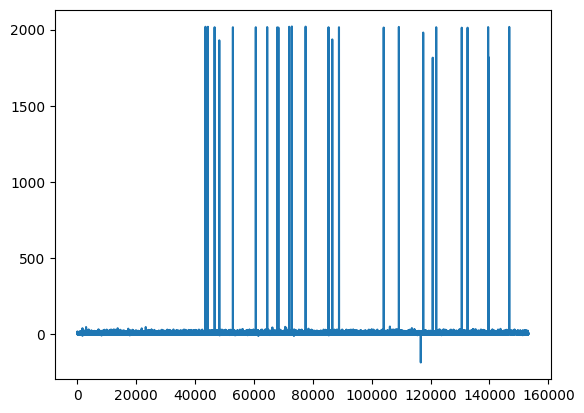

In [160]:
import matplotlib.pyplot as plt
plt.plot(df.experience)

In [161]:
df['experience'].value_counts()

,count
experience,
2.0,20868
3.0,20176
4.0,17896
1.0,16168
5.0,14876
...,...
-186.0,1
119.0,1
1981.0,1


In [162]:
#Experiece clean-up
df = df[~((df['experience'] > 25) | (df['experience'] < 0))]

In [163]:
df['experience'].value_counts()

,count
experience,
2.0,20868
3.0,20176
4.0,17896
1.0,16168
5.0,14876
6.0,11638
7.0,9093
0.0,8346
8.0,6799


In [164]:
job_map_df.head()

,Original,New
0,7,others
1,91,others
2,737,others
3,857628,others
4,896651,others


In [165]:
df.head()

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,2020.0,others,4.0
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,2019.0,fullstack devloper,1.0
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,2020.0,backend engineer,5.0
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,2019.0,backend engineer,2.0
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,2019.0,fullstack devloper,2.0


In [166]:
df['job_position_clean'].isna().count()

np.int64(147883)

In [167]:
job_map_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Original  801 non-null    object
 1   New       801 non-null    object
dtypes: object(2)
memory usage: 12.6+ KB


In [168]:
df.dropna(inplace=True)
df.count()

,0
company_hash,147100
email_hash,147100
orgyear,147100
ctc,147100
ctc_updated_year,147100
job_position_clean,147100
experience,147100


In [169]:
df.ctc.min()

2

In [170]:
df.ctc.max()

200000000

In [171]:
lower = df['ctc'].quantile(0.05)
upper = df['ctc'].quantile(0.99)

df = df[(df['ctc'] >= lower) & (df['ctc'] <= upper)]


In [172]:
df.ctc.max()

13000000

In [173]:
df.ctc.min()


200000

In [174]:
df[df['ctc'] == 200000]

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience
61,qini,03f3f5604f4fd3abcefc1b07e5525fe0b8513b13652be3...,2016.0,200000,2019.0,others,3.0
82,takuceku,1f5dc52a9c357d9f314f449b8c195cec80d95205d21c96...,2018.0,200000,2021.0,others,3.0
116,jszwzle findwsiuf,d726e41fff8cf17c98d40bd5445fa20690c4363415a3b7...,2018.0,200000,2021.0,fullstack devloper,3.0
176,fsutfaf fibwmkoz jvw nwc,9fb5df0df799ecddabdcc4235eab560b09b6d108c492e8...,2019.0,200000,2019.0,fullstack devloper,0.0
193,kgesjok lkjswkn,f1bb8aabadbf145df05bce086f890efa558e5705b4579a...,2019.0,200000,2019.0,fullstack devloper,0.0
...,...,...,...,...,...,...,...
152530,nzi wzleuifibw,0b728f3b385709dac9ab377d3e0925be2659229f700916...,2017.0,200000,2020.0,backend engineer,3.0
152671,bozfezof,b3ea45ae465e5a7aab4c3a411b60be66be6878be5b5dd5...,2018.0,200000,2020.0,others,2.0
152683,gzkdwi fafwzhf,cb68a80928d8e50221918d2af2e74470ecbac2696ea582...,2017.0,200000,2021.0,backend engineer,4.0
152692,lnslr wezokjzdwslf,9355efa41fb5740dcb82c90f033d6a56a87811095ef793...,2018.0,200000,2021.0,backend engineer,3.0


In [175]:
df.head()

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,2020.0,others,4.0
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,2019.0,fullstack devloper,1.0
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,2020.0,backend engineer,5.0
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,2019.0,backend engineer,2.0
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,2019.0,fullstack devloper,2.0


In [176]:
#Checking unique emails and frequency of occurrence of the same email hash in the data. Recording observation and inference, wherever necessary.
tmp = df['email_hash'].value_counts().reset_index()

In [177]:
tmp

,email_hash,count
0,6842660273f70e9aa239026ba33bfe82275d6ab0d20124...,9
1,3e5e49daa5527a6d5a33599b238bf9bf31e85b9efa9a94...,9
2,bbace3cc586400bbc65765bc6a16b77d8913836cfc98b7...,8
3,298528ce3160cc761e4dc37a07337ee2e0589df251d736...,8
4,c0eb129061675da412b0deb15871dd06ef0d7cd86eb5f7...,8
...,...,...
120583,36cea4f76d85ce12e03d02cb461d7dc4d5c9dd9560990b...,1
120584,67f721d083ad4a47137d75173fad0840124f2d17fc6fda...,1
120585,fd21ec71881a44fce61c5a25a9d1c6e4713207b843c845...,1
120586,9428bdb40ad39856a30ea4451fbf5daf416773df765b28...,1


In [178]:
tmp = tmp[tmp['count'] > 1]

In [179]:
tmp

,email_hash,count
0,6842660273f70e9aa239026ba33bfe82275d6ab0d20124...,9
1,3e5e49daa5527a6d5a33599b238bf9bf31e85b9efa9a94...,9
2,bbace3cc586400bbc65765bc6a16b77d8913836cfc98b7...,8
3,298528ce3160cc761e4dc37a07337ee2e0589df251d736...,8
4,c0eb129061675da412b0deb15871dd06ef0d7cd86eb5f7...,8
...,...,...
15228,2997066f4abb5c04679e91e2efc88a329e8efd0f4dc060...,2
15229,61a0372b4f6eb184baf97387c7efce6f2d2dd72b779862...,2
15230,822e0ec77d3992dde6ae9c540cab3884366811331ba6b7...,2
15231,3ef5d23c4b2fb264268fe1497188a87b97d6287a2a5259...,2


In [180]:
tmp['count'].value_counts()

,count
count,
2,12663
3,2015
4,455
5,69
6,20
7,6
8,3
9,2


In [181]:
tmp = tmp.rename(columns={'count' : 'offer_count'})

In [182]:
tmp

,email_hash,offer_count
0,6842660273f70e9aa239026ba33bfe82275d6ab0d20124...,9
1,3e5e49daa5527a6d5a33599b238bf9bf31e85b9efa9a94...,9
2,bbace3cc586400bbc65765bc6a16b77d8913836cfc98b7...,8
3,298528ce3160cc761e4dc37a07337ee2e0589df251d736...,8
4,c0eb129061675da412b0deb15871dd06ef0d7cd86eb5f7...,8
...,...,...
15228,2997066f4abb5c04679e91e2efc88a329e8efd0f4dc060...,2
15229,61a0372b4f6eb184baf97387c7efce6f2d2dd72b779862...,2
15230,822e0ec77d3992dde6ae9c540cab3884366811331ba6b7...,2
15231,3ef5d23c4b2fb264268fe1497188a87b97d6287a2a5259...,2


In [183]:
df['ctc_updated_year'].describe()

,ctc_updated_year
count,139095.000000
mean,2019.587095
std,1.230781
min,2015.000000
25%,2019.000000
50%,2020.000000
75%,2021.000000
max,2021.000000


In [184]:
df['orgyear'].describe()

,orgyear
count,139095.000000
mean,2014.702556
std,4.080635
min,1992.000000
25%,2013.000000
50%,2016.000000
75%,2018.000000
max,2021.000000


In [185]:
df['ctc_updated_year'].isna().count()

np.int64(139095)

In [186]:
df = df.reset_index(drop=True)

In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139095 entries, 0 to 139094
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   company_hash        139095 non-null  object 
 1   email_hash          139095 non-null  object 
 2   orgyear             139095 non-null  float64
 3   ctc                 139095 non-null  int64  
 4   ctc_updated_year    139095 non-null  float64
 5   job_position_clean  139095 non-null  object 
 6   experience          139095 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 7.4+ MB


In [188]:
df = df.merge(tmp,
              how = 'left',
              left_on='email_hash',
              right_on='email_hash')

In [189]:
df

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience,offer_count
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,2020.0,others,4.0,2.0
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,2019.0,fullstack devloper,1.0,2.0
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,2020.0,backend engineer,5.0,2.0
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,2019.0,backend engineer,2.0,NaN
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,2019.0,fullstack devloper,2.0,2.0
...,...,...,...,...,...,...,...,...
139090,lft suwzoukwsiukn,ee1e251ebb54cffeddc09244bbc0ed122a1cf59511bbc1...,2016.0,1500000,2021.0,fullstack devloper,5.0,2.0
139091,subifaf,aec7061c552cfd56fe635ca0e9d347d2e63a95dbcd2ef8...,2019.0,1200000,2021.0,fullstack devloper,2.0,NaN
139092,lihjuivk liuwoklw,251f5f33672f58c65f43e94d0fc0fef69a7f6149b3b4db...,2015.0,1000000,2021.0,data scientist,6.0,2.0
139093,cduuedhga,617a49afbc5efc0f1692780d20fc566ba4ed4f1125491c...,2019.0,1100000,2021.0,data scientist,2.0,NaN


In [190]:
df['offer_count'] = df.offer_count.fillna(1)

In [191]:
df

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience,offer_count
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,2020.0,others,4.0,2.0
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,2019.0,fullstack devloper,1.0,2.0
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,2020.0,backend engineer,5.0,2.0
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,2019.0,backend engineer,2.0,1.0
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,2019.0,fullstack devloper,2.0,2.0
...,...,...,...,...,...,...,...,...
139090,lft suwzoukwsiukn,ee1e251ebb54cffeddc09244bbc0ed122a1cf59511bbc1...,2016.0,1500000,2021.0,fullstack devloper,5.0,2.0
139091,subifaf,aec7061c552cfd56fe635ca0e9d347d2e63a95dbcd2ef8...,2019.0,1200000,2021.0,fullstack devloper,2.0,1.0
139092,lihjuivk liuwoklw,251f5f33672f58c65f43e94d0fc0fef69a7f6149b3b4db...,2015.0,1000000,2021.0,data scientist,6.0,2.0
139093,cduuedhga,617a49afbc5efc0f1692780d20fc566ba4ed4f1125491c...,2019.0,1100000,2021.0,data scientist,2.0,1.0


how many folks got multiple offers offer_count > 1 in same year and diff_year



In [192]:
df_gr_email_ctcupyear = df.groupby(['email_hash','ctc_updated_year']).size().reset_index(name='offer_count')


In [193]:
df_gr_email_ctcupyear.head()

,email_hash,ctc_updated_year,offer_count
0,00003288036a44374976948c327f246fdbdf0778546904...,2019.0,1
1,0000aaa0e6b61f7636af1954b43d294484cd151c9b3cf6...,2020.0,1
2,000120d0c8aa304fcf12ab4b85e21feb80a342cfea03d4...,2021.0,1
3,0001b94dbb1e85477b07fb6558ead3456c3735893c81f4...,2020.0,1
4,0001b94dbb1e85477b07fb6558ead3456c3735893c81f4...,2021.0,1


In [194]:
df_multi_offer_same_year = df_gr_email_ctcupyear[ df_gr_email_ctcupyear['offer_count'] > 1]

In [195]:
df_multi_offer_same_year

,email_hash,ctc_updated_year,offer_count
14,00083d053a4ebf8e8eb99c08c63e0183a70caa0ce348a5...,2020.0,2
36,001059a637996b0b09d5fcbcd8b40d8e1f6cfa62b18b10...,2021.0,2
45,00154fd1e62658a3caa5f7e3260b6338293ee614235bcb...,2020.0,2
51,0018d91337b46826a70a961962abbd7a8a8e8036e678bc...,2020.0,3
56,001b3125da5372767bc5c560066e7e53525f2aece726e6...,2019.0,3
...,...,...,...
125648,ffe288a7eb673fcd177e4a933e3c090f15e95b938a8c0e...,2020.0,2
125650,ffe407064ff7580666a650bb87a212a99435775b42e5aa...,2021.0,2
125656,ffe8b4edc31c9e237a8068b3a94224628f05dac96041fb...,2021.0,2
125657,ffe96dccfd7cb9e6048a382bbdc511be147ceaa7de3ada...,2019.0,2


In [196]:
len(df_multi_offer_same_year) / len(df) * 100

8.391387181422768

#Conclusion 1 : 8.21% of the folks got multiple offers in the same Year

** Manual Clustering ** on the basis of learner’s company, job position and years of experience

Getting the 5 point summary of CTC (mean, median, max, min, count etc) on the basis of Company, Job Position, Years of Experience

Merging the same with original dataset carefully and creating some flags showing learners with CTC greater than the Average of their Company’s department having same Years of Experience - Call that flag designation with values [1,2,3]
Doing above analysis at Company & Job Position level. Name that flag Class with values [1,2,3]
Repeating the same analysis at the Company level. Name that flag Tier with values [1,2,3]
Based on the manual clustering done so far, answering few questions like:
Top 10 employees (earning more than most of the employees in the company) - Tier 1
Top 10 employees of data science in each company earning more than their peers - Class 1
Bottom 10 employees of data science in each company earning less than their peers - Class 3
Bottom 10 employees (earning less than most of the employees in the company)- Tier 3
Top 10 employees in each company - X department - having 5/6/7 years of experience earning more than their peers - Tier X
Top 10 companies (based on their CTC)
Top 2 positions in every company (based on their CTC)
Data processing for Unsupervised clustering - Label encoding/ One- hot encoding, Standardization of data

In [197]:
df.head()

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience,offer_count
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,2020.0,others,4.0,2.0
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,2019.0,fullstack devloper,1.0,2.0
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,2020.0,backend engineer,5.0,2.0
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,2019.0,backend engineer,2.0,1.0
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,2019.0,fullstack devloper,2.0,2.0


In [198]:
#Getting the 5 point summary of CTC (mean, median, max, min, count etc) on the basis of Company, Job Position, Years of Experience
gr_ctc = df.groupby(['company_hash','job_position_clean','experience'])['ctc'].agg(
        count='count',
        mean='mean',
        median='median',
        min='min',
        max='max'
    ).reset_index()


In [199]:
gr_ctc

,company_hash,job_position_clean,experience,count,mean,median,min,max
0,0000,others,3.0,1,300000.0,300000.0,300000,300000
1,01 fauzota,android engineer,3.0,1,270000.0,270000.0,270000,270000
2,01 fauzota,frontend developer,8.0,1,830000.0,830000.0,830000,830000
3,05gu bsuezknwe josvkwz nshswzc,backend engineer,2.0,1,1100000.0,1100000.0,1100000,1100000
4,1 azko,backend engineer,1.0,2,1180000.0,1180000.0,660000,1700000
...,...,...,...,...,...,...,...,...
83140,zzhzqz fibw wzle,frontend developer,8.0,1,1000000.0,1000000.0,1000000,1000000
83141,zzm wzleuinitszf,devops engineer,5.0,1,800000.0,800000.0,800000,800000
83142,zzm wzleuinitszf,others,5.0,1,800000.0,800000.0,800000,800000
83143,zzqansbz sul,fullstack devloper,2.0,1,710000.0,710000.0,710000,710000


In [200]:
gr_ctc[gr_ctc['count']>1]

,company_hash,job_position_clean,experience,count,mean,median,min,max
4,1 azko,backend engineer,1.0,2,1.180000e+06,1180000.0,660000,1700000
15,10wshzf,fullstack devloper,1.0,2,4.050000e+05,405000.0,400000,410000
35,1fsnvzogdnnzw,fullstack devloper,1.0,2,1.100000e+06,1100000.0,1100000,1100000
41,1ht,android engineer,1.0,2,7.500000e+05,750000.0,600000,900000
44,1ht,backend engineer,1.0,2,1.100000e+06,1100000.0,1000000,1200000
...,...,...,...,...,...,...,...,...
83055,zywokhkorf,others,1.0,3,6.500000e+05,600000.0,550000,800000
83074,zywozhz uzwmiorf,backend engineer,2.0,3,1.116667e+06,1050000.0,1050000,1250000
83075,zywozhz uzwmiorf,backend engineer,3.0,4,1.175000e+06,1300000.0,800000,1300000
83076,zywozhz uzwmiorf,backend engineer,6.0,2,1.750000e+06,1750000.0,1500000,2000000


In [201]:
mrg_col = ['company_hash','job_position_clean','experience']
df_mrg_ctc = df.merge(gr_ctc,'left',left_on=mrg_col, right_on=mrg_col)

In [202]:
df_mrg_ctc

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience,offer_count,count,mean,median,min,max
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,2020.0,others,4.0,2.0,2,1.085000e+06,1085000.0,1070000,1100000
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,2019.0,fullstack devloper,1.0,2.0,2,4.599995e+05,459999.5,449999,470000
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,2020.0,backend engineer,5.0,2.0,1,2.000000e+06,2000000.0,2000000,2000000
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,2019.0,backend engineer,2.0,1.0,10,1.344000e+06,1375000.0,700000,1950000
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,2019.0,fullstack devloper,2.0,2.0,2,1.000000e+06,1000000.0,600000,1400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
139090,lft suwzoukwsiukn,ee1e251ebb54cffeddc09244bbc0ed122a1cf59511bbc1...,2016.0,1500000,2021.0,fullstack devloper,5.0,2.0,1,1.500000e+06,1500000.0,1500000,1500000
139091,subifaf,aec7061c552cfd56fe635ca0e9d347d2e63a95dbcd2ef8...,2019.0,1200000,2021.0,fullstack devloper,2.0,1.0,172,5.439243e+05,420000.0,300000,1800000
139092,lihjuivk liuwoklw,251f5f33672f58c65f43e94d0fc0fef69a7f6149b3b4db...,2015.0,1000000,2021.0,data scientist,6.0,2.0,1,1.000000e+06,1000000.0,1000000,1000000
139093,cduuedhga,617a49afbc5efc0f1692780d20fc566ba4ed4f1125491c...,2019.0,1100000,2021.0,data scientist,2.0,1.0,2,1.150000e+06,1150000.0,1100000,1200000


In [203]:
df_mrg_ctc['ctc_above_avg'] = df_mrg_ctc.apply(lambda row: 1 if row['ctc'] > row['mean'] else 0, axis=1)

In [204]:
import numpy as np

df_mrg_ctc['ctc_status'] = np.where(
    df_mrg_ctc['ctc'] < df_mrg_ctc['mean'],
    1,                                      # lower than avg
    np.where(
        df_mrg_ctc['ctc'] > df_mrg_ctc['mean'],
        3,                                  # above avg
        2                                   # equal to avg
    )
)


In [205]:
df_mrg_ctc.head()

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience,offer_count,count,mean,median,min,max,ctc_above_avg,ctc_status
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,2020.0,others,4.0,2.0,2,1085000.0,1085000.0,1070000,1100000,1,3
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,2019.0,fullstack devloper,1.0,2.0,2,459999.5,459999.5,449999,470000,0,1
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,2020.0,backend engineer,5.0,2.0,1,2000000.0,2000000.0,2000000,2000000,0,2
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,2019.0,backend engineer,2.0,1.0,10,1344000.0,1375000.0,700000,1950000,0,1
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,2019.0,fullstack devloper,2.0,2.0,2,1000000.0,1000000.0,600000,1400000,1,3


In [206]:
df_mrg_ctc

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience,offer_count,count,mean,median,min,max,ctc_above_avg,ctc_status
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,2020.0,others,4.0,2.0,2,1.085000e+06,1085000.0,1070000,1100000,1,3
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,2019.0,fullstack devloper,1.0,2.0,2,4.599995e+05,459999.5,449999,470000,0,1
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,2020.0,backend engineer,5.0,2.0,1,2.000000e+06,2000000.0,2000000,2000000,0,2
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,2019.0,backend engineer,2.0,1.0,10,1.344000e+06,1375000.0,700000,1950000,0,1
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,2019.0,fullstack devloper,2.0,2.0,2,1.000000e+06,1000000.0,600000,1400000,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139090,lft suwzoukwsiukn,ee1e251ebb54cffeddc09244bbc0ed122a1cf59511bbc1...,2016.0,1500000,2021.0,fullstack devloper,5.0,2.0,1,1.500000e+06,1500000.0,1500000,1500000,0,2
139091,subifaf,aec7061c552cfd56fe635ca0e9d347d2e63a95dbcd2ef8...,2019.0,1200000,2021.0,fullstack devloper,2.0,1.0,172,5.439243e+05,420000.0,300000,1800000,1,3
139092,lihjuivk liuwoklw,251f5f33672f58c65f43e94d0fc0fef69a7f6149b3b4db...,2015.0,1000000,2021.0,data scientist,6.0,2.0,1,1.000000e+06,1000000.0,1000000,1000000,0,2
139093,cduuedhga,617a49afbc5efc0f1692780d20fc566ba4ed4f1125491c...,2019.0,1100000,2021.0,data scientist,2.0,1.0,2,1.150000e+06,1150000.0,1100000,1200000,0,1


In [207]:
gr_ctc_company_job = df.groupby(['company_hash','job_position_clean'])['ctc'].agg(
        mean='mean',
        median='median',
        min='min',
        max='max'
    ).reset_index()

In [208]:
gr_ctc_company_job.rename(columns={'mean':'cp_jb_mean', 'median':'cp_jb_median', 'min':'cp_jb_min','max' : 'cp_jb_max'},inplace=True)

In [209]:
gr_ctc_company_job

,company_hash,job_position_clean,cp_jb_mean,cp_jb_median,cp_jb_min,cp_jb_max
0,0000,others,300000.0,300000.0,300000,300000
1,01 fauzota,android engineer,270000.0,270000.0,270000,270000
2,01 fauzota,frontend developer,830000.0,830000.0,830000,830000
3,05gu bsuezknwe josvkwz nshswzc,backend engineer,1100000.0,1100000.0,1100000,1100000
4,1 azko,backend engineer,1180000.0,1180000.0,660000,1700000
...,...,...,...,...,...,...
51958,zzhzqz fibw wzle,frontend developer,1000000.0,1000000.0,1000000,1000000
51959,zzm wzleuinitszf,devops engineer,800000.0,800000.0,800000,800000
51960,zzm wzleuinitszf,others,800000.0,800000.0,800000,800000
51961,zzqansbz sul,fullstack devloper,710000.0,710000.0,710000,710000


In [210]:
mrg_col = ['company_hash','job_position_clean']
df_mrg_ctc = df_mrg_ctc.merge(gr_ctc_company_job,'left',left_on=mrg_col, right_on=mrg_col)

In [211]:
df_mrg_ctc

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience,offer_count,count,mean,median,min,max,ctc_above_avg,ctc_status,cp_jb_mean,cp_jb_median,cp_jb_min,cp_jb_max
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,2020.0,others,4.0,2.0,2,1.085000e+06,1085000.0,1070000,1100000,1,3,1.085000e+06,1085000.0,1070000,1100000
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,2019.0,fullstack devloper,1.0,2.0,2,4.599995e+05,459999.5,449999,470000,0,1,9.882000e+05,850000.0,300000,2000000
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,2020.0,backend engineer,5.0,2.0,1,2.000000e+06,2000000.0,2000000,2000000,0,2,2.000000e+06,2000000.0,2000000,2000000
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,2019.0,backend engineer,2.0,1.0,10,1.344000e+06,1375000.0,700000,1950000,0,1,1.563043e+06,1600000.0,520000,3500000
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,2019.0,fullstack devloper,2.0,2.0,2,1.000000e+06,1000000.0,600000,1400000,1,3,8.466667e+05,600000.0,540000,1400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139090,lft suwzoukwsiukn,ee1e251ebb54cffeddc09244bbc0ed122a1cf59511bbc1...,2016.0,1500000,2021.0,fullstack devloper,5.0,2.0,1,1.500000e+06,1500000.0,1500000,1500000,0,2,1.546250e+06,1610000.0,550000,2500000
139091,subifaf,aec7061c552cfd56fe635ca0e9d347d2e63a95dbcd2ef8...,2019.0,1200000,2021.0,fullstack devloper,2.0,1.0,172,5.439243e+05,420000.0,300000,1800000,1,3,6.515222e+05,500000.0,200000,6500000
139092,lihjuivk liuwoklw,251f5f33672f58c65f43e94d0fc0fef69a7f6149b3b4db...,2015.0,1000000,2021.0,data scientist,6.0,2.0,1,1.000000e+06,1000000.0,1000000,1000000,0,2,1.000000e+06,1000000.0,1000000,1000000
139093,cduuedhga,617a49afbc5efc0f1692780d20fc566ba4ed4f1125491c...,2019.0,1100000,2021.0,data scientist,2.0,1.0,2,1.150000e+06,1150000.0,1100000,1200000,0,1,1.301621e+06,1200000.0,467000,2510000


In [212]:
df_mrg_ctc['ctc_cp_jb_status'] = np.where(
    df_mrg_ctc['ctc'] < df_mrg_ctc['cp_jb_mean'],
    1,                                      # lower than avg
    np.where(
        df_mrg_ctc['ctc'] > df_mrg_ctc['cp_jb_mean'],
        3,                                  # above avg
        2                                   # equal to avg
    )
)

In [213]:
df_mrg_ctc

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience,offer_count,count,mean,median,min,max,ctc_above_avg,ctc_status,cp_jb_mean,cp_jb_median,cp_jb_min,cp_jb_max,ctc_cp_jb_status
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,2020.0,others,4.0,2.0,2,1.085000e+06,1085000.0,1070000,1100000,1,3,1.085000e+06,1085000.0,1070000,1100000,3
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,2019.0,fullstack devloper,1.0,2.0,2,4.599995e+05,459999.5,449999,470000,0,1,9.882000e+05,850000.0,300000,2000000,1
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,2020.0,backend engineer,5.0,2.0,1,2.000000e+06,2000000.0,2000000,2000000,0,2,2.000000e+06,2000000.0,2000000,2000000,2
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,2019.0,backend engineer,2.0,1.0,10,1.344000e+06,1375000.0,700000,1950000,0,1,1.563043e+06,1600000.0,520000,3500000,1
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,2019.0,fullstack devloper,2.0,2.0,2,1.000000e+06,1000000.0,600000,1400000,1,3,8.466667e+05,600000.0,540000,1400000,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139090,lft suwzoukwsiukn,ee1e251ebb54cffeddc09244bbc0ed122a1cf59511bbc1...,2016.0,1500000,2021.0,fullstack devloper,5.0,2.0,1,1.500000e+06,1500000.0,1500000,1500000,0,2,1.546250e+06,1610000.0,550000,2500000,1
139091,subifaf,aec7061c552cfd56fe635ca0e9d347d2e63a95dbcd2ef8...,2019.0,1200000,2021.0,fullstack devloper,2.0,1.0,172,5.439243e+05,420000.0,300000,1800000,1,3,6.515222e+05,500000.0,200000,6500000,3
139092,lihjuivk liuwoklw,251f5f33672f58c65f43e94d0fc0fef69a7f6149b3b4db...,2015.0,1000000,2021.0,data scientist,6.0,2.0,1,1.000000e+06,1000000.0,1000000,1000000,0,2,1.000000e+06,1000000.0,1000000,1000000,2
139093,cduuedhga,617a49afbc5efc0f1692780d20fc566ba4ed4f1125491c...,2019.0,1100000,2021.0,data scientist,2.0,1.0,2,1.150000e+06,1150000.0,1100000,1200000,0,1,1.301621e+06,1200000.0,467000,2510000,1


In [214]:
gr_ctc_company = df.groupby(['company_hash'])['ctc'].agg(mean='mean',
        median='median',
        min='min',
        max='max'
    ).reset_index()

In [215]:
gr_ctc_company.rename(columns={'mean':'cp_mean', 'median':'cp_median', 'min':'cp_min','max' : 'cp_max'},inplace=True)

In [216]:
gr_ctc_company

,company_hash,cp_mean,cp_median,cp_min,cp_max
0,0000,300000.0,300000.0,300000,300000
1,01 fauzota,550000.0,550000.0,270000,830000
2,05gu bsuezknwe josvkwz nshswzc,1100000.0,1100000.0,1100000,1100000
3,1 azko,1180000.0,1180000.0,660000,1700000
4,1 cstswknf,350000.0,350000.0,350000,350000
...,...,...,...,...,...
29984,zzhjekfaf nwc,1526000.0,1526000.0,1526000,1526000
29985,zzhzqz fibw wzle,1000000.0,1000000.0,1000000,1000000
29986,zzm wzleuinitszf,800000.0,800000.0,800000,800000
29987,zzqansbz sul,710000.0,710000.0,710000,710000


In [217]:
mrg_col = ['company_hash']
df_mrg_ctc = df_mrg_ctc.merge(gr_ctc_company,'left',left_on=mrg_col, right_on=mrg_col)

In [218]:
df_mrg_ctc

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience,offer_count,count,mean,...,ctc_status,cp_jb_mean,cp_jb_median,cp_jb_min,cp_jb_max,ctc_cp_jb_status,cp_mean,cp_median,cp_min,cp_max
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,2020.0,others,4.0,2.0,2,1.085000e+06,...,3,1.085000e+06,1085000.0,1070000,1100000,3,1.115667e+06,1070000.0,500000,1771000
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,2019.0,fullstack devloper,1.0,2.0,2,4.599995e+05,...,1,9.882000e+05,850000.0,300000,2000000,1,1.196112e+06,900000.0,200000,6000000
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,2020.0,backend engineer,5.0,2.0,1,2.000000e+06,...,2,2.000000e+06,2000000.0,2000000,2000000,2,2.000000e+06,2000000.0,2000000,2000000
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,2019.0,backend engineer,2.0,1.0,10,1.344000e+06,...,1,1.563043e+06,1600000.0,520000,3500000,1,1.673367e+06,1450000.0,200000,4700000
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,2019.0,fullstack devloper,2.0,2.0,2,1.000000e+06,...,3,8.466667e+05,600000.0,540000,1400000,3,9.880000e+05,1000000.0,540000,1400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139090,lft suwzoukwsiukn,ee1e251ebb54cffeddc09244bbc0ed122a1cf59511bbc1...,2016.0,1500000,2021.0,fullstack devloper,5.0,2.0,1,1.500000e+06,...,2,1.546250e+06,1610000.0,550000,2500000,1,1.380294e+06,1100000.0,550000,4300000
139091,subifaf,aec7061c552cfd56fe635ca0e9d347d2e63a95dbcd2ef8...,2019.0,1200000,2021.0,fullstack devloper,2.0,1.0,172,5.439243e+05,...,3,6.515222e+05,500000.0,200000,6500000,3,6.590659e+05,500000.0,200000,12350000
139092,lihjuivk liuwoklw,251f5f33672f58c65f43e94d0fc0fef69a7f6149b3b4db...,2015.0,1000000,2021.0,data scientist,6.0,2.0,1,1.000000e+06,...,2,1.000000e+06,1000000.0,1000000,1000000,2,1.000000e+06,1000000.0,1000000,1000000
139093,cduuedhga,617a49afbc5efc0f1692780d20fc566ba4ed4f1125491c...,2019.0,1100000,2021.0,data scientist,2.0,1.0,2,1.150000e+06,...,1,1.301621e+06,1200000.0,467000,2510000,1,1.328455e+06,1200000.0,467000,2510000


In [219]:
len(df_mrg_ctc.ctc_updated_year.unique())

7

In [220]:
df_mrg_ctc['ctc_cp_status'] = np.where(
    df_mrg_ctc['ctc'] < df_mrg_ctc['cp_mean'],
    1,                                      # lower than avg
    np.where(
        df_mrg_ctc['ctc'] > df_mrg_ctc['cp_mean'],
        3,                                  # above avg
        2                                   # equal to avg
    )
)

In [221]:
df_mrg_ctc

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience,offer_count,count,mean,...,cp_jb_mean,cp_jb_median,cp_jb_min,cp_jb_max,ctc_cp_jb_status,cp_mean,cp_median,cp_min,cp_max,ctc_cp_status
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,2020.0,others,4.0,2.0,2,1.085000e+06,...,1.085000e+06,1085000.0,1070000,1100000,3,1.115667e+06,1070000.0,500000,1771000,1
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,2019.0,fullstack devloper,1.0,2.0,2,4.599995e+05,...,9.882000e+05,850000.0,300000,2000000,1,1.196112e+06,900000.0,200000,6000000,1
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,2020.0,backend engineer,5.0,2.0,1,2.000000e+06,...,2.000000e+06,2000000.0,2000000,2000000,2,2.000000e+06,2000000.0,2000000,2000000,2
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,2019.0,backend engineer,2.0,1.0,10,1.344000e+06,...,1.563043e+06,1600000.0,520000,3500000,1,1.673367e+06,1450000.0,200000,4700000,1
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,2019.0,fullstack devloper,2.0,2.0,2,1.000000e+06,...,8.466667e+05,600000.0,540000,1400000,3,9.880000e+05,1000000.0,540000,1400000,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139090,lft suwzoukwsiukn,ee1e251ebb54cffeddc09244bbc0ed122a1cf59511bbc1...,2016.0,1500000,2021.0,fullstack devloper,5.0,2.0,1,1.500000e+06,...,1.546250e+06,1610000.0,550000,2500000,1,1.380294e+06,1100000.0,550000,4300000,3
139091,subifaf,aec7061c552cfd56fe635ca0e9d347d2e63a95dbcd2ef8...,2019.0,1200000,2021.0,fullstack devloper,2.0,1.0,172,5.439243e+05,...,6.515222e+05,500000.0,200000,6500000,3,6.590659e+05,500000.0,200000,12350000,3
139092,lihjuivk liuwoklw,251f5f33672f58c65f43e94d0fc0fef69a7f6149b3b4db...,2015.0,1000000,2021.0,data scientist,6.0,2.0,1,1.000000e+06,...,1.000000e+06,1000000.0,1000000,1000000,2,1.000000e+06,1000000.0,1000000,1000000,2
139093,cduuedhga,617a49afbc5efc0f1692780d20fc566ba4ed4f1125491c...,2019.0,1100000,2021.0,data scientist,2.0,1.0,2,1.150000e+06,...,1.301621e+06,1200000.0,467000,2510000,1,1.328455e+06,1200000.0,467000,2510000,1


##Top 10 employees (earning more than most of the employees in the company) - Tier 1

In [222]:
df_mrg_ctc['ctc_rank_cp'] = df_mrg_ctc.groupby('company_hash')['ctc'].rank(method='dense',ascending=False)

top10_emp_per_cp = df_mrg_ctc[df_mrg_ctc['ctc_rank_cp'] < 11]
print(top10_emp_per_cp[ ['email_hash','company_hash', 'job_position_clean','experience','ctc']].head(30).to_string(index=False))

                                                      email_hash                                  company_hash     job_position_clean  experience      ctc
6de0a4417d18ab14334c3f43397fc13b30c35149d70c050c0618caea697c87af                                czniswwz sucsk                 others         4.0  1100000
4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e90fd66c9df6b37b9059                                 faulwklwsl ks       backend engineer         5.0  2000000
6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520214b31b95211adb095                                    osbw toidj     fullstack devloper         2.0  1400000
18f2c4aa2ac9dd3ae8ff74f32d30413f5165565b90d8f21a44173a1f73fbb0f2           ekjjsna duhkooszc hkorzwsut jvw nwc     fullstack devloper         2.0   700000
756d35a7f6bb8ffeaffc8fcca9ddbb78e7450fa0de2be0a5e9c8d98eb87f97f9                          kllzuwdoz wzleuinita       backend engineer         0.0   400000
72c2171a022115d475c8faac306912a4c95f6dd7fdd320df09a5e9160d2a8385      

In [223]:
top10_emp_per_cp

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience,offer_count,count,mean,...,cp_jb_median,cp_jb_min,cp_jb_max,ctc_cp_jb_status,cp_mean,cp_median,cp_min,cp_max,ctc_cp_status,ctc_rank_cp
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,2020.0,others,4.0,2.0,2,1085000.0,...,1085000.0,1070000,1100000,3,1.115667e+06,1070000.0,500000,1771000,1,4.0
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,2020.0,backend engineer,5.0,2.0,1,2000000.0,...,2000000.0,2000000,2000000,2,2.000000e+06,2000000.0,2000000,2000000,2,1.0
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,2019.0,fullstack devloper,2.0,2.0,2,1000000.0,...,600000.0,540000,1400000,3,9.880000e+05,1000000.0,540000,1400000,3,1.0
5,ekjjsna duhkooszc hkorzwsut jvw nwc,18f2c4aa2ac9dd3ae8ff74f32d30413f5165565b90d8f2...,2018.0,700000,2020.0,fullstack devloper,2.0,2.0,1,700000.0,...,700000.0,700000,700000,2,9.066667e+05,700000.0,620000,2000000,1,3.0
7,kllzuwdoz wzleuinita,756d35a7f6bb8ffeaffc8fcca9ddbb78e7450fa0de2be0...,2019.0,400000,2019.0,backend engineer,0.0,1.0,1,400000.0,...,1005000.0,400000,3500000,1,8.740000e+05,640000.0,300000,3500000,1,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139081,fkhfdut oc sufwswdwz sucsk gkutknioz,9428bdb40ad39856a30ea4451fbf5daf416773df765b28...,2018.0,2400000,2021.0,backend engineer,3.0,1.0,1,2400000.0,...,2400000.0,2400000,2400000,2,2.000000e+06,2000000.0,1600000,2400000,3,1.0
139083,lkotsnn,2e23f5a7124dfb3b8179c49aa09e3f623af67b946413d8...,2020.0,1600000,2021.0,fullstack devloper,1.0,1.0,1,1600000.0,...,1635000.0,1600000,1670000,1,1.161000e+06,1100000.0,500000,2400000,3,3.0
139090,lft suwzoukwsiukn,ee1e251ebb54cffeddc09244bbc0ed122a1cf59511bbc1...,2016.0,1500000,2021.0,fullstack devloper,5.0,2.0,1,1500000.0,...,1610000.0,550000,2500000,1,1.380294e+06,1100000.0,550000,4300000,3,7.0
139092,lihjuivk liuwoklw,251f5f33672f58c65f43e94d0fc0fef69a7f6149b3b4db...,2015.0,1000000,2021.0,data scientist,6.0,2.0,1,1000000.0,...,1000000.0,1000000,1000000,2,1.000000e+06,1000000.0,1000000,1000000,2,1.0


## Conclusion 2 : Top 10 employees (earning more than most of the employees in the company) - Tier 1

In [224]:

# Sort by company first, then by CTC descending
df_mrg_ctc_sorted = df_mrg_ctc.sort_values(['company_hash', 'ctc'], ascending=[True, False])

# For each company, take the top 10 earners
top10_per_company = df_mrg_ctc_sorted.groupby('company_hash').head(10)

print(top10_per_company[['company_hash','email_hash','ctc']].head(20).to_string(index=False))


                   company_hash                                                       email_hash      ctc
                           0000 b3f3bb98cbca4b1ce5dfd5abb4e500ce6f6b66288a5202ead573964201d24b24   300000
                     01 fauzota e1e15fada844f35fcc33927343d0c80f55526b87c40eeed72b25ceafc1186e5e   830000
                     01 fauzota 819789ff4068fd5c8facf8a5074cdd2e1ff989c95ae02c02b81ac1447cbd6386   270000
 05gu bsuezknwe josvkwz nshswzc 4702229ffb6968c87b16fc57e730769e554184e322e1118fbd997a1d8e50dec0  1100000
                         1 azko 034ae72dd3b77497e96173751f8805d5314bc2363e30c213137be4a5065dd1ef  1700000
                         1 azko 26a4487b5be40da1e942bf3bc1189172727de0e1c74c5eb7cc77b591fa97fff1   660000
                     1 cstswknf 70459269ec53bd863dc3bad03772c608842ce6182710e1ad40e66b1ebe578baf   350000
      10 cstswkn  cdgks  niuciu dbe475d9ad7bfb41d4fffe71787b26f8dadf1f12885ed8e7f12642dc9e27dc52  1300000
                    1000joipzlw 8e617c175a9b2b

## Conclusion 5 : Top 2 positions in every company (based on their CTC)


In [225]:
# For each company, take the top 2 earners
top2_per_company = df_mrg_ctc_sorted.groupby('company_hash').head(2)
print(f"Top 2 Positions in every company based on their CTC")
print(top2_per_company[['company_hash','job_position_clean','ctc']].head(20).to_string(index=False))

Top 2 Positions in every company based on their CTC
                   company_hash job_position_clean      ctc
                           0000             others   300000
                     01 fauzota frontend developer   830000
                     01 fauzota   android engineer   270000
 05gu bsuezknwe josvkwz nshswzc   backend engineer  1100000
                         1 azko   backend engineer  1700000
                         1 azko   backend engineer   660000
                     1 cstswknf   backend engineer   350000
      10 cstswkn  cdgks  niuciu   android engineer  1300000
                    1000joipzlw frontend developer   600000
                      1001 kjjf frontend developer  1650000
                        100jsuf engineering intern   900000
            103 fwdcsif jvw nwc frontend developer   320000
             10bk sucsk jvw nwc       data analyst   880000
10r subi ckwk findwsiuf jvw nwc fullstack devloper  1100000
                            10s   android engine

#Conclusion 2 : Bottom 10 employees (earning less than most of the employees in the company)- Tier 3

In [226]:
# Sort by company first, then by CTC ascending
df_mrg_ctc_sorted_asc = df_mrg_ctc.sort_values(['company_hash', 'ctc'], ascending=[True, True])

# For each company, take the bottom 10 earners
Bottom10_per_company = df_mrg_ctc_sorted_asc.groupby('company_hash').head(10)

print(Bottom10_per_company[['company_hash','email_hash','ctc','ctc_rank_cp']].head(200).to_string(index=False))

                              company_hash                                                       email_hash      ctc  ctc_rank_cp
                                      0000 b3f3bb98cbca4b1ce5dfd5abb4e500ce6f6b66288a5202ead573964201d24b24   300000          1.0
                                01 fauzota 819789ff4068fd5c8facf8a5074cdd2e1ff989c95ae02c02b81ac1447cbd6386   270000          2.0
                                01 fauzota e1e15fada844f35fcc33927343d0c80f55526b87c40eeed72b25ceafc1186e5e   830000          1.0
            05gu bsuezknwe josvkwz nshswzc 4702229ffb6968c87b16fc57e730769e554184e322e1118fbd997a1d8e50dec0  1100000          1.0
                                    1 azko 26a4487b5be40da1e942bf3bc1189172727de0e1c74c5eb7cc77b591fa97fff1   660000          2.0
                                    1 azko 034ae72dd3b77497e96173751f8805d5314bc2363e30c213137be4a5065dd1ef  1700000          1.0
                                1 cstswknf 70459269ec53bd863dc3bad03772c608842ce6182710e1a

## Conclusion 3 : Top 10 employees of data science in each company earning more than their peers - Class 1


In [227]:
df_data_scientist = df_mrg_ctc_sorted[df_mrg_ctc_sorted['job_position_clean'].str.contains('data scientist',case = False, na=False)]

In [228]:
# For each company, take the top 10 earners in data science

top10_data_scientist_per_company = df_data_scientist.groupby('company_hash').head(10)
print(f" **** Top10_data_scientist_per_company ***\n")
print(top10_data_scientist_per_company[['company_hash','email_hash','ctc','job_position_clean']].head(20).to_string(index=False))


 **** Top10_data_scientist_per_company ***

                   company_hash                                                       email_hash     ctc job_position_clean
                 10yks nzkousut 48be30753b1dbf2c2fccf43b7f45c51d68bb5725f4ae764fe457adb66df350af  400000     data scientist
                            1ht 6b01808bba4c2d50258b068274232251620630cb252a9c09804ea9f7bbef4d8f 1100000     data scientist
                            1ht eb213c0552effd7fb139395c7838edb8d59773a1cb57a00ddeac0e4885fb302a  800000     data scientist
                           1tzu 3dddd88f7d7ac6ace0dfd4927d881a9d452a3666c692bf2d392410c50e8d15c2  400000     data scientist
1tzu jnkwbioh findwsiuf jvw nwc 4f4d3137aebfdc15fc4626314308ef082fd2dde54ef9f17fda9e18dc7ea3188f  500000     data scientist
                 1z subifafwzhf c659650daaf7f10c6c6627b33627b4c7749892cfd941d0a6a652d22366105438 3300000     data scientist
                   24 fzvzu sul dd209a8b4616576d23c8efecfa5c21d473b15023ed27c74b6d76f694

## Conclusion 4 Bottom 10 employees of data science in each company earning less than their peers - Class 3

In [229]:
# For each company, take the bottom 10 earners in data science

bottom10_data_scientist_per_company = df_data_scientist.groupby('company_hash').tail(10)
print(f" **** Bottom 10_data_scientist_per_company ***\n")
print(bottom10_data_scientist_per_company[['company_hash','email_hash','ctc','job_position_clean','ctc_rank_cp']].head(500).to_string(index=False))


 **** Bottom 10_data_scientist_per_company ***

                                          company_hash                                                       email_hash      ctc job_position_clean  ctc_rank_cp
                                        10yks nzkousut 48be30753b1dbf2c2fccf43b7f45c51d68bb5725f4ae764fe457adb66df350af   400000     data scientist          1.0
                                                   1ht 6b01808bba4c2d50258b068274232251620630cb252a9c09804ea9f7bbef4d8f  1100000     data scientist         17.0
                                                   1ht eb213c0552effd7fb139395c7838edb8d59773a1cb57a00ddeac0e4885fb302a   800000     data scientist         20.0
                                                  1tzu 3dddd88f7d7ac6ace0dfd4927d881a9d452a3666c692bf2d392410c50e8d15c2   400000     data scientist          3.0
                       1tzu jnkwbioh findwsiuf jvw nwc 4f4d3137aebfdc15fc4626314308ef082fd2dde54ef9f17fda9e18dc7ea3188f   500000     data scientist

##Conclusion 5: Top 10 companies (based on their CTC)


In [230]:
df_mrg_ctc_sorted.head()

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience,offer_count,count,mean,...,cp_jb_median,cp_jb_min,cp_jb_max,ctc_cp_jb_status,cp_mean,cp_median,cp_min,cp_max,ctc_cp_status,ctc_rank_cp
134097,0000,b3f3bb98cbca4b1ce5dfd5abb4e500ce6f6b66288a5202...,2017.0,300000,2020.0,others,3.0,1.0,1,300000.0,...,300000.0,300000,300000,2,300000.0,300000.0,300000,300000,2,1.0
34982,01 fauzota,e1e15fada844f35fcc33927343d0c80f55526b87c40eee...,2011.0,830000,2019.0,frontend developer,8.0,1.0,1,830000.0,...,830000.0,830000,830000,2,550000.0,550000.0,270000,830000,3,1.0
47362,01 fauzota,819789ff4068fd5c8facf8a5074cdd2e1ff989c95ae02c...,2016.0,270000,2019.0,android engineer,3.0,1.0,1,270000.0,...,270000.0,270000,270000,2,550000.0,550000.0,270000,830000,1,2.0
92292,05gu bsuezknwe josvkwz nshswzc,4702229ffb6968c87b16fc57e730769e554184e322e111...,2019.0,1100000,2021.0,backend engineer,2.0,1.0,1,1100000.0,...,1100000.0,1100000,1100000,2,1100000.0,1100000.0,1100000,1100000,2,1.0
64530,1 azko,034ae72dd3b77497e96173751f8805d5314bc2363e30c2...,2018.0,1700000,2019.0,backend engineer,1.0,1.0,2,1180000.0,...,1180000.0,660000,1700000,3,1180000.0,1180000.0,660000,1700000,3,1.0


In [231]:
tmp = df_mrg_ctc_sorted.sort_values('ctc',ascending=False)
print(f"Top 10 companies Based on their CTC")
tmp.head(10)[['company_hash','ctc']]

Top 10 companies Based on their CTC


,company_hash,ctc
130317,joicdlw liufdnwkuw wkwk lnsx hktslgoslrf hdnws...,13000000
74223,giirsutlih,13000000
77827,giirsutlih,13000000
13130,khzoslku zyjozff,13000000
33810,khcilf,13000000
100940,ioklnz,13000000
66551,vsfk,13000000
59677,wosjkcvsfio,13000000
70577,eznjfesbw,13000000
104250,ezykmkoz wzleuinitszf,13000000


In [235]:
#Designation (within Company + Job + Experience)

grp = df_mrg_ctc.groupby(['company_hash', 'job_position_clean', 'experience'])['ctc'].transform('mean')
df_mrg_ctc['Designation'] = np.where(df_mrg_ctc['ctc'] > grp, 1,
                      np.where(df_mrg_ctc['ctc'] < grp, 3, 2))


In [236]:
df_mrg_ctc

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience,offer_count,count,mean,...,cp_jb_min,cp_jb_max,ctc_cp_jb_status,cp_mean,cp_median,cp_min,cp_max,ctc_cp_status,ctc_rank_cp,Designation
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,2020.0,others,4.0,2.0,2,1.085000e+06,...,1070000,1100000,3,1.115667e+06,1070000.0,500000,1771000,1,4.0,1
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,2019.0,fullstack devloper,1.0,2.0,2,4.599995e+05,...,300000,2000000,1,1.196112e+06,900000.0,200000,6000000,1,105.0,3
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,2020.0,backend engineer,5.0,2.0,1,2.000000e+06,...,2000000,2000000,2,2.000000e+06,2000000.0,2000000,2000000,2,1.0,2
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,2019.0,backend engineer,2.0,1.0,10,1.344000e+06,...,520000,3500000,1,1.673367e+06,1450000.0,200000,4700000,1,29.0,3
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,2019.0,fullstack devloper,2.0,2.0,2,1.000000e+06,...,540000,1400000,3,9.880000e+05,1000000.0,540000,1400000,3,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139090,lft suwzoukwsiukn,ee1e251ebb54cffeddc09244bbc0ed122a1cf59511bbc1...,2016.0,1500000,2021.0,fullstack devloper,5.0,2.0,1,1.500000e+06,...,550000,2500000,1,1.380294e+06,1100000.0,550000,4300000,3,7.0,2
139091,subifaf,aec7061c552cfd56fe635ca0e9d347d2e63a95dbcd2ef8...,2019.0,1200000,2021.0,fullstack devloper,2.0,1.0,172,5.439243e+05,...,200000,6500000,3,6.590659e+05,500000.0,200000,12350000,3,79.0,1
139092,lihjuivk liuwoklw,251f5f33672f58c65f43e94d0fc0fef69a7f6149b3b4db...,2015.0,1000000,2021.0,data scientist,6.0,2.0,1,1.000000e+06,...,1000000,1000000,2,1.000000e+06,1000000.0,1000000,1000000,2,1.0,2
139093,cduuedhga,617a49afbc5efc0f1692780d20fc566ba4ed4f1125491c...,2019.0,1100000,2021.0,data scientist,2.0,1.0,2,1.150000e+06,...,467000,2510000,1,1.328455e+06,1200000.0,467000,2510000,1,17.0,3


In [237]:
#Class (within company + job)
grp_cj = df_mrg_ctc.groupby(['company_hash', 'job_position_clean'])['ctc'].transform('mean')
df_mrg_ctc['Class'] = np.where(df_mrg_ctc['ctc'] > grp_cj, 1,
                np.where(df_mrg_ctc['ctc'] < grp_cj, 3, 2))

In [239]:
df_mrg_ctc

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience,offer_count,count,mean,...,cp_jb_max,ctc_cp_jb_status,cp_mean,cp_median,cp_min,cp_max,ctc_cp_status,ctc_rank_cp,Designation,Class
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,2020.0,others,4.0,2.0,2,1.085000e+06,...,1100000,3,1.115667e+06,1070000.0,500000,1771000,1,4.0,1,1
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,2019.0,fullstack devloper,1.0,2.0,2,4.599995e+05,...,2000000,1,1.196112e+06,900000.0,200000,6000000,1,105.0,3,3
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,2020.0,backend engineer,5.0,2.0,1,2.000000e+06,...,2000000,2,2.000000e+06,2000000.0,2000000,2000000,2,1.0,2,2
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,2019.0,backend engineer,2.0,1.0,10,1.344000e+06,...,3500000,1,1.673367e+06,1450000.0,200000,4700000,1,29.0,3,3
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,2019.0,fullstack devloper,2.0,2.0,2,1.000000e+06,...,1400000,3,9.880000e+05,1000000.0,540000,1400000,3,1.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139090,lft suwzoukwsiukn,ee1e251ebb54cffeddc09244bbc0ed122a1cf59511bbc1...,2016.0,1500000,2021.0,fullstack devloper,5.0,2.0,1,1.500000e+06,...,2500000,1,1.380294e+06,1100000.0,550000,4300000,3,7.0,2,3
139091,subifaf,aec7061c552cfd56fe635ca0e9d347d2e63a95dbcd2ef8...,2019.0,1200000,2021.0,fullstack devloper,2.0,1.0,172,5.439243e+05,...,6500000,3,6.590659e+05,500000.0,200000,12350000,3,79.0,1,1
139092,lihjuivk liuwoklw,251f5f33672f58c65f43e94d0fc0fef69a7f6149b3b4db...,2015.0,1000000,2021.0,data scientist,6.0,2.0,1,1.000000e+06,...,1000000,2,1.000000e+06,1000000.0,1000000,1000000,2,1.0,2,2
139093,cduuedhga,617a49afbc5efc0f1692780d20fc566ba4ed4f1125491c...,2019.0,1100000,2021.0,data scientist,2.0,1.0,2,1.150000e+06,...,2510000,1,1.328455e+06,1200000.0,467000,2510000,1,17.0,3,3


In [240]:
#Tier (within Company)

grp_c = df.groupby('company_hash')['ctc'].transform('mean')
df_mrg_ctc['Tier'] = np.where(df_mrg_ctc['ctc'] > grp_c, 1,
               np.where(df_mrg_ctc['ctc'] < grp_c, 3, 2))


In [241]:
df_mrg_ctc

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience,offer_count,count,mean,...,ctc_cp_jb_status,cp_mean,cp_median,cp_min,cp_max,ctc_cp_status,ctc_rank_cp,Designation,Class,Tier
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,2020.0,others,4.0,2.0,2,1.085000e+06,...,3,1.115667e+06,1070000.0,500000,1771000,1,4.0,1,1,3
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,2019.0,fullstack devloper,1.0,2.0,2,4.599995e+05,...,1,1.196112e+06,900000.0,200000,6000000,1,105.0,3,3,3
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,2020.0,backend engineer,5.0,2.0,1,2.000000e+06,...,2,2.000000e+06,2000000.0,2000000,2000000,2,1.0,2,2,2
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,2019.0,backend engineer,2.0,1.0,10,1.344000e+06,...,1,1.673367e+06,1450000.0,200000,4700000,1,29.0,3,3,3
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,2019.0,fullstack devloper,2.0,2.0,2,1.000000e+06,...,3,9.880000e+05,1000000.0,540000,1400000,3,1.0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139090,lft suwzoukwsiukn,ee1e251ebb54cffeddc09244bbc0ed122a1cf59511bbc1...,2016.0,1500000,2021.0,fullstack devloper,5.0,2.0,1,1.500000e+06,...,1,1.380294e+06,1100000.0,550000,4300000,3,7.0,2,3,1
139091,subifaf,aec7061c552cfd56fe635ca0e9d347d2e63a95dbcd2ef8...,2019.0,1200000,2021.0,fullstack devloper,2.0,1.0,172,5.439243e+05,...,3,6.590659e+05,500000.0,200000,12350000,3,79.0,1,1,1
139092,lihjuivk liuwoklw,251f5f33672f58c65f43e94d0fc0fef69a7f6149b3b4db...,2015.0,1000000,2021.0,data scientist,6.0,2.0,1,1.000000e+06,...,2,1.000000e+06,1000000.0,1000000,1000000,2,1.0,2,2,2
139093,cduuedhga,617a49afbc5efc0f1692780d20fc566ba4ed4f1125491c...,2019.0,1100000,2021.0,data scientist,2.0,1.0,2,1.150000e+06,...,1,1.328455e+06,1200000.0,467000,2510000,1,17.0,3,3,3


In [243]:
#Top 10 Tier-1 highest earner
top_10_tier1 = (
    df_mrg_ctc[df_mrg_ctc['Tier'] == 1]
    .sort_values('ctc', ascending=False)
    .head(10)
)

top_10_tier1

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience,offer_count,count,mean,...,ctc_cp_jb_status,cp_mean,cp_median,cp_min,cp_max,ctc_cp_status,ctc_rank_cp,Designation,Class,Tier
70577,eznjfesbw,e1e429ec570026d5490f59ff56063e01ccd9554fa76c2a...,2007.0,13000000,2019.0,engineering leadership,12.0,1.0,1,13000000.0,...,3,3.082000e+06,2170000.0,420000,13000000,3,1.0,2,1,1
13130,khzoslku zyjozff,d1b8ec80f9cdfe002bd7ce9477686e0a3c204364cd8cea...,2016.0,13000000,2020.0,frontend developer,4.0,1.0,1,13000000.0,...,3,1.914923e+06,1650000.0,350000,13000000,3,1.0,2,1,1
33810,khcilf,90f5f4f4f372dc9fbafae24405d4a67acda41a3f69fddb...,2004.0,13000000,2017.0,engineering leadership,13.0,1.0,2,8000000.0,...,3,9.705719e+05,750000.0,225000,13000000,3,1.0,1,1,1
74223,giirsutlih,c202a6f3a97ba5dc184fd3629caf92c04f0308ca32e24b...,2013.0,13000000,2020.0,engineering leadership,7.0,4.0,2,12000000.0,...,3,5.602568e+06,5000000.0,200000,13000000,3,1.0,1,1,1
85836,fwkuckoc lekowzozc gkur,a59217afe3715636db88ad82dd65b4fb79562b28349ba9...,2010.0,13000000,2020.0,backend architect,10.0,1.0,1,13000000.0,...,3,1.923293e+06,1705000.0,250000,13000000,3,1.0,2,1,1
106322,cznn zhl,480149b83bb51d170038021c1d04a8b5278e3309e380fe...,2016.0,13000000,2017.0,others,1.0,1.0,1,13000000.0,...,3,1.874924e+06,1430000.0,200000,13000000,3,1.0,2,1,1
104250,ezykmkoz wzleuinitszf,7efc0d01949f7ebcc4f95faf5b9131a0d1be6618c6a756...,2004.0,13000000,2019.0,engineering leadership,15.0,1.0,1,13000000.0,...,3,1.027451e+06,835000.0,250000,13000000,3,1.0,2,1,1
66551,vsfk,07fa362afb1e8317dd55ebbfe79d7177e64f7c951e0e43...,2011.0,13000000,2020.0,backend engineer,9.0,1.0,2,7600000.0,...,3,2.541624e+06,2040000.0,200000,13000000,3,1.0,1,1,1
77827,giirsutlih,c202a6f3a97ba5dc184fd3629caf92c04f0308ca32e24b...,2013.0,13000000,2020.0,backend engineer,7.0,4.0,5,9900000.0,...,3,5.602568e+06,5000000.0,200000,13000000,3,1.0,1,1,1
50257,bnsjrkow,a850072678a95692f59d8549d37510d3538be5e21468de...,2005.0,13000000,2019.0,backend architect,14.0,1.0,1,13000000.0,...,3,2.904165e+06,2650000.0,200000,13000000,3,1.0,2,1,1


#Conclusion 11 : Top 10 Tier-1 Highest earner

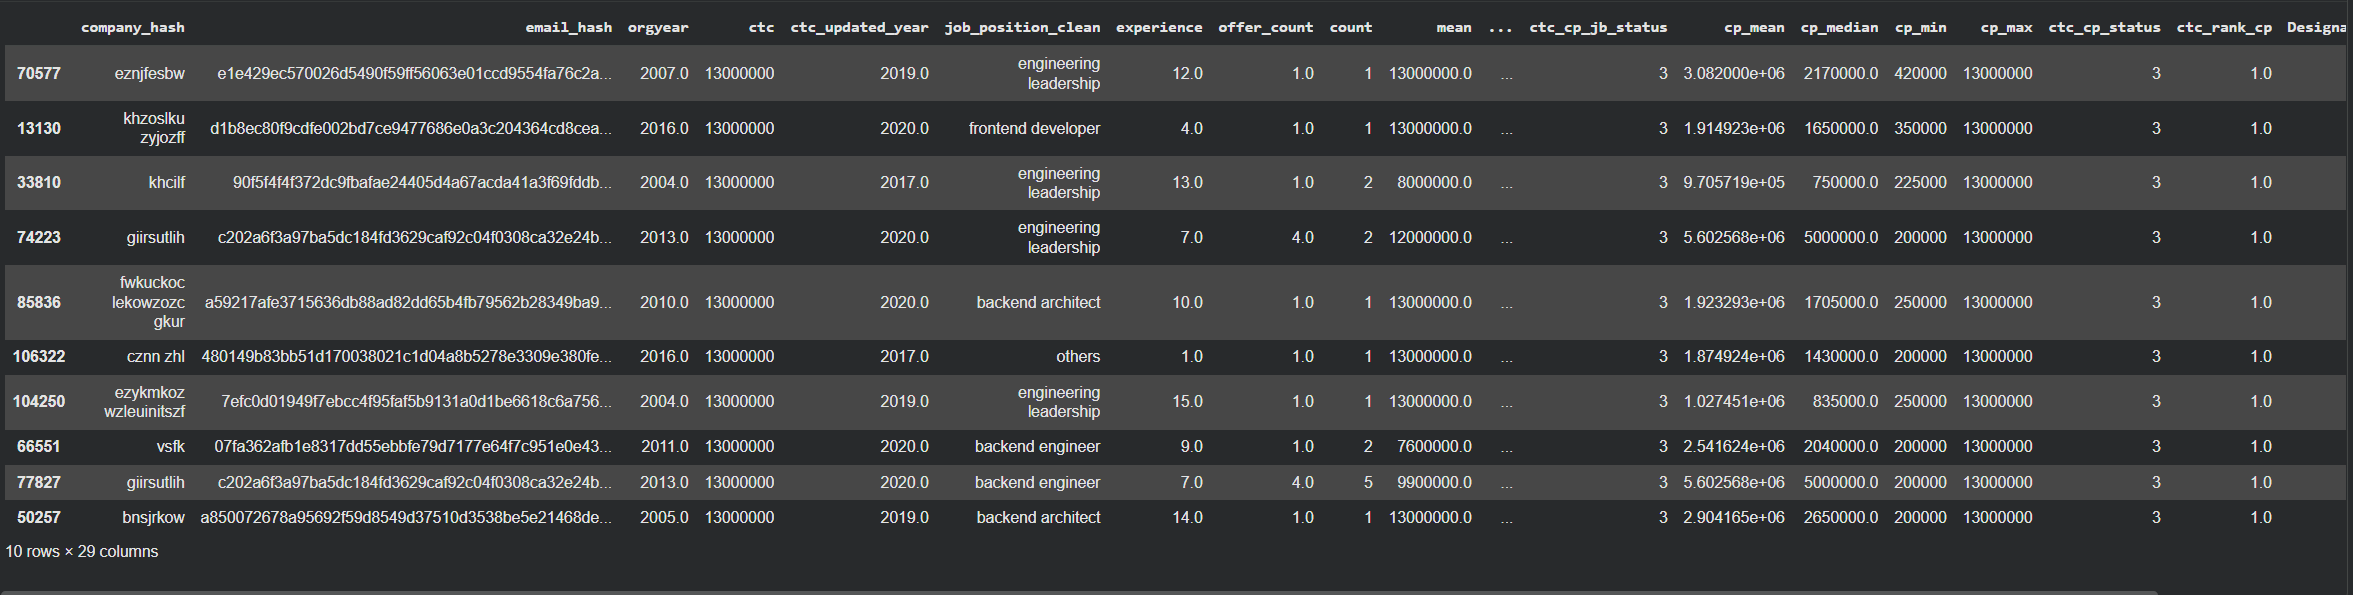

In [245]:
#Top 10 Data scientist in terms of CTC in each company
ds_filter = df_mrg_ctc['job_position_clean'].str.contains('data scientist', case=False)

top_10_class1_ds = (
    df_mrg_ctc[(df_mrg_ctc['Class'] == 1) & (ds_filter)]
    .sort_values(['company_hash', 'ctc'], ascending=[True, False])
    .groupby('company_hash')
    .head(10)
)

top_10_class1_ds

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience,offer_count,count,mean,...,ctc_cp_jb_status,cp_mean,cp_median,cp_min,cp_max,ctc_cp_status,ctc_rank_cp,Designation,Class,Tier
92151,1ht,6b01808bba4c2d50258b068274232251620630cb252a9c...,2018.0,1100000,2021.0,data scientist,3.0,2.0,1,1100000.0,...,3,1.474762e+06,1350000.0,600000,3750000,1,17.0,2,1,3
93587,247ks,9d2537610d57179230806bb77258f63c3134b8fde9aa3a...,2010.0,2600000,2015.0,data scientist,5.0,1.0,1,2600000.0,...,3,1.662213e+06,1350000.0,200000,7000000,3,8.0,2,1,1
58210,247ks,ddd9683a58865398ed934ee7faeb0825e515f2fe3cdaad...,2008.0,2500000,2019.0,data scientist,11.0,1.0,1,2500000.0,...,3,1.662213e+06,1350000.0,200000,7000000,3,9.0,2,1,1
69615,3nix,a372713f7d18e6f03b5b469cbd1ddb8145c2688597c528...,2014.0,1710000,2019.0,data scientist,5.0,1.0,2,1155000.0,...,3,1.341818e+06,1100000.0,600000,2600000,3,2.0,1,1,1
9191,3nix,c27536d2fe174089c62eca78e6e643baef88a6100c1404...,2010.0,1500000,2021.0,data scientist,11.0,2.0,1,1500000.0,...,3,1.341818e+06,1100000.0,600000,2600000,3,3.0,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95014,zyn,4334b84443fd1df68862927b09ed1108194750b421edd4...,2017.0,1210000,2019.0,data scientist,2.0,3.0,4,915000.0,...,3,9.107292e+05,825000.0,325000,1950000,3,8.0,1,1,1
65115,zyn,7f00726d182f514b7b7276df44564b6ffcb37b9bcaf83b...,2015.0,1200000,2021.0,data scientist,6.0,2.0,1,1200000.0,...,3,9.107292e+05,825000.0,325000,1950000,3,9.0,2,1,1
101165,zyn,7bebf8a495a6da4e7d8dc307bfb5e3f0976c6ee46584b3...,2016.0,1100000,2019.0,data scientist,3.0,1.0,4,945000.0,...,3,9.107292e+05,825000.0,325000,1950000,3,10.0,1,1,1
107284,zyn,ea243d24cae974118cd02cd9922a55a833e9750b41ed2e...,2016.0,1100000,2020.0,data scientist,4.0,1.0,4,1197500.0,...,3,9.107292e+05,825000.0,325000,1950000,3,10.0,3,1,1


## Conclusion 12: Top 10 Data scientist in terms of CTC in each company

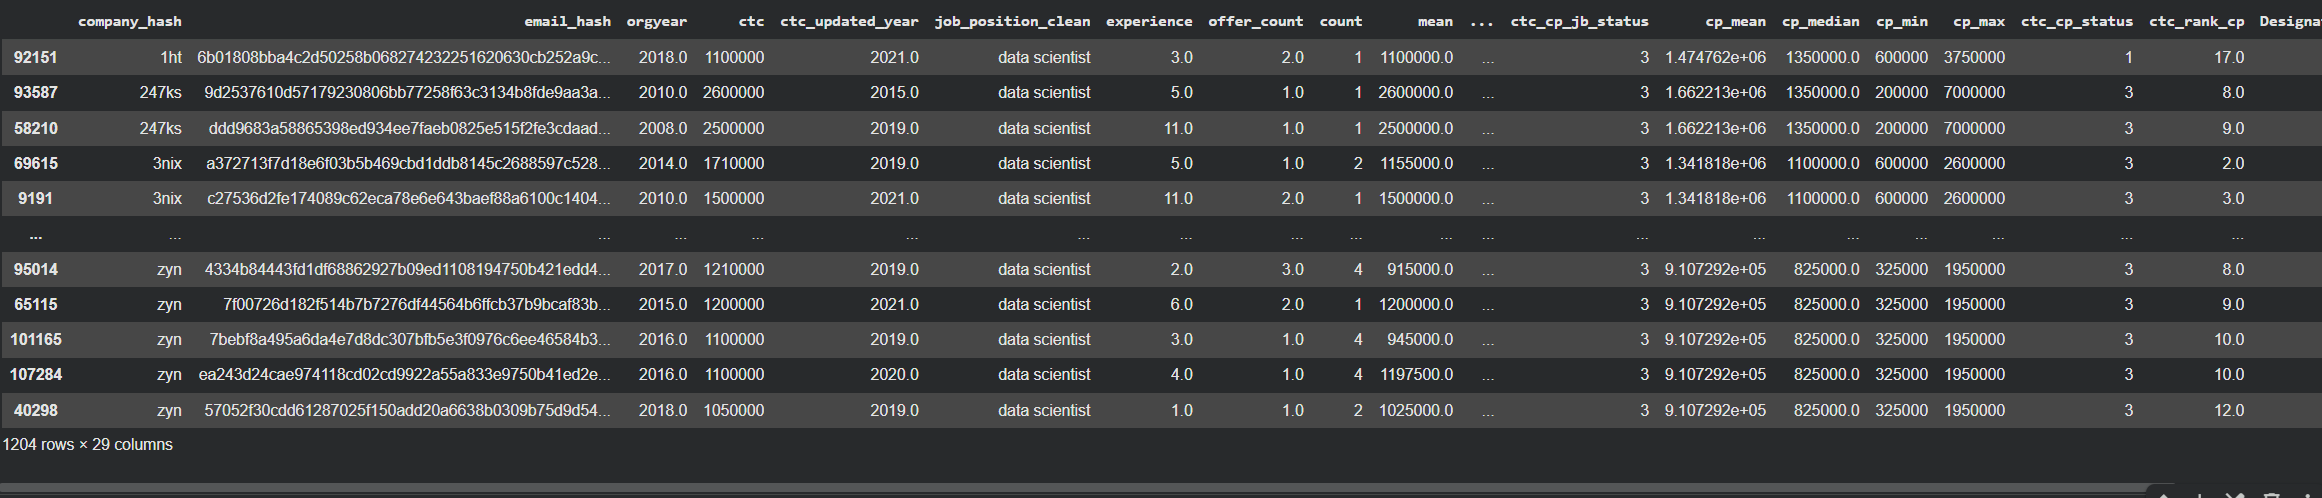

In [247]:
#Bottom 10 class 3 employees for data science by company
bottom_10_class3_ds = (
    df_mrg_ctc[(df_mrg_ctc['Class'] == 3) & (ds_filter)]
    .sort_values(['company_hash', 'ctc'], ascending=[True, True])
    .groupby('company_hash')
    .head(10)
)

bottom_10_class3_ds

,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience,offer_count,count,mean,...,ctc_cp_jb_status,cp_mean,cp_median,cp_min,cp_max,ctc_cp_status,ctc_rank_cp,Designation,Class,Tier
119950,1ht,eb213c0552effd7fb139395c7838edb8d59773a1cb57a0...,1994.0,800000,2019.0,data scientist,25.0,1.0,1,800000.0,...,1,1.474762e+06,1350000.0,600000,3750000,1,20.0,2,3,3
99490,247ks,5f4b52a1c2539fe2e4b29a8470bc57dbace331b819a0af...,2002.0,1440000,2019.0,data scientist,17.0,1.0,1,1440000.0,...,1,1.662213e+06,1350000.0,200000,7000000,1,20.0,2,3,3
45437,247ks,c35054c043f6a02da3e6f142fbcb095f8145eb521137ff...,2014.0,2150000,2018.0,data scientist,4.0,1.0,1,2150000.0,...,1,1.662213e+06,1350000.0,200000,7000000,3,13.0,2,3,1
88500,3nix,24db964005796c656431df0b035768e8b9cee21f8cf425...,2015.0,600000,2020.0,data scientist,5.0,2.0,2,1155000.0,...,1,1.341818e+06,1100000.0,600000,2600000,1,8.0,3,3,3
94419,3nix,5c67aa9b1414eb0dc68b6acc70c978f0b429e1f24f32a9...,2018.0,800000,2019.0,data scientist,1.0,1.0,1,800000.0,...,1,1.341818e+06,1100000.0,600000,2600000,1,6.0,2,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72635,zyn,aafa88e4eac24a3d61624b864e1099e1614b2ff4a8ba31...,2018.0,600000,2020.0,data scientist,2.0,1.0,4,915000.0,...,1,9.107292e+05,825000.0,325000,1950000,1,23.0,3,3,3
80865,zyn,fc5b32ac4858bcf7348e01385929d88fd135a54c382f19...,2016.0,600000,2019.0,data scientist,3.0,1.0,4,945000.0,...,1,9.107292e+05,825000.0,325000,1950000,1,23.0,3,3,3
111123,zyn,1737de7fae03e35d71fa56b6d4f191239eea499dcaf784...,2016.0,680000,2019.0,data scientist,3.0,2.0,4,945000.0,...,1,9.107292e+05,825000.0,325000,1950000,1,21.0,3,3,3
91665,zyn,e4116b5f6df007ed1d4dafb3fc9dcf9d2425a771092551...,2016.0,950000,2020.0,data scientist,4.0,2.0,4,1197500.0,...,1,9.107292e+05,825000.0,325000,1950000,3,14.0,3,3,1


## Conclusion : 13 : Bottom 10 class 3 employees for data science by company
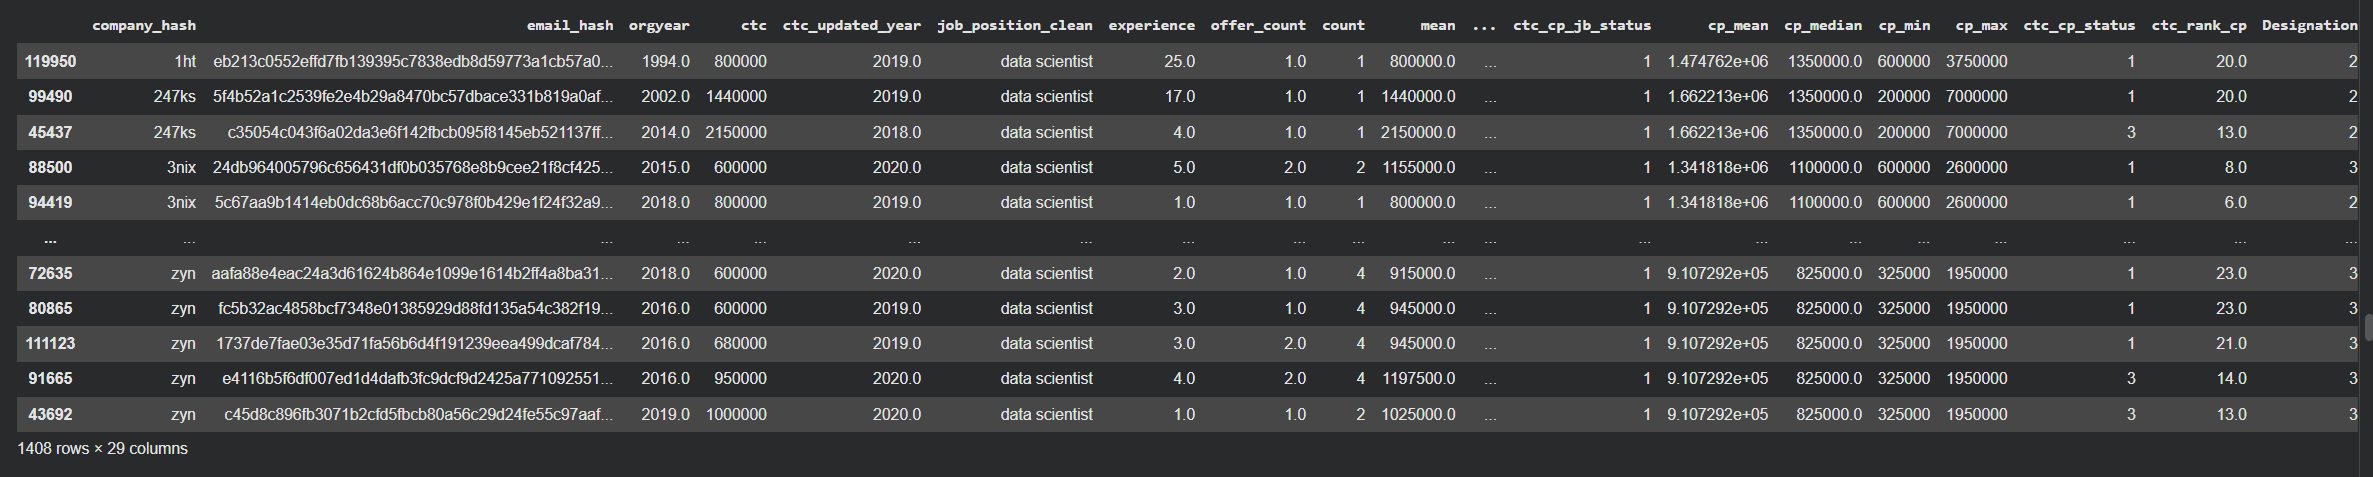


In [248]:
#Top 10 employees in each company with 5/6/7 years of experience (Tier‑X)

#For Experience = 5
top_10_exp5 = (
    df_mrg_ctc[df_mrg_ctc['experience'] == 5]
    .sort_values(['company_hash', 'ctc'], ascending=[True, False])
    .groupby('company_hash')
    .head(10)
)

top_10_exp5


,company_hash,email_hash,orgyear,ctc,ctc_updated_year,job_position_clean,experience,offer_count,count,mean,...,ctc_cp_jb_status,cp_mean,cp_median,cp_min,cp_max,ctc_cp_status,ctc_rank_cp,Designation,Class,Tier
17878,1985,0e0b52e1fa76e607ca155769bbfb978c4dc91b7482df27...,2015.0,1100000,2020.0,backend engineer,5.0,2.0,1,1100000.0,...,2,1.100000e+06,1100000.0,1100000,1100000,2,1.0,2,2,2
41416,1ht,a58fadbfbc00c007dfe6e5d5891f2dda013eb5cc66552a...,2014.0,1600000,2019.0,backend engineer,5.0,3.0,1,1600000.0,...,3,1.474762e+06,1350000.0,600000,3750000,3,11.0,2,1,1
87011,1ht,a58fadbfbc00c007dfe6e5d5891f2dda013eb5cc66552a...,2014.0,1600000,2019.0,fullstack devloper,5.0,3.0,1,1600000.0,...,3,1.474762e+06,1350000.0,600000,3750000,3,11.0,2,1,1
32437,1ht,70ba1dbf1441301553fc165d293bf11243c242b12f7132...,2012.0,1500000,2017.0,others,5.0,1.0,1,1500000.0,...,2,1.474762e+06,1350000.0,600000,3750000,3,12.0,2,2,1
138488,1ht wzleuinitszf jvw nwc,70ba4ee689ae53a942d5a9dffe2ceae1d776ca5736e69e...,2015.0,2800000,2020.0,fullstack devloper,5.0,1.0,1,2800000.0,...,3,1.295385e+06,1000000.0,300000,3500000,3,2.0,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73549,zyznk wzleuinitszf,fc32499aea13089305dd7cca847d22f40fb6113142f0ac...,2015.0,400000,2020.0,fullstack devloper,5.0,2.0,1,400000.0,...,1,1.100000e+06,1100000.0,400000,1800000,1,2.0,2,3,3
66378,zyztzfsf subiwzle,29054fc1fc86832b4cc011489734fb631d283733655ade...,2015.0,436000,2020.0,support engineer,5.0,1.0,1,436000.0,...,2,4.360000e+05,436000.0,436000,436000,2,1.0,2,2,2
67978,zzm wzleuinitszf,048d7bae3f37c3e13a7c25addb1b1e8237c144ab9d7b66...,2016.0,800000,2021.0,devops engineer,5.0,2.0,1,800000.0,...,2,8.000000e+05,800000.0,800000,800000,2,1.0,2,2,2
92753,zzm wzleuinitszf,048d7bae3f37c3e13a7c25addb1b1e8237c144ab9d7b66...,2016.0,800000,2021.0,others,5.0,2.0,1,800000.0,...,2,8.000000e+05,800000.0,800000,800000,2,1.0,2,2,2


## Conclusion 14 : Top 10 employees in each company with 5/6/7 years of experience (Tier‑X) For Experience = 5
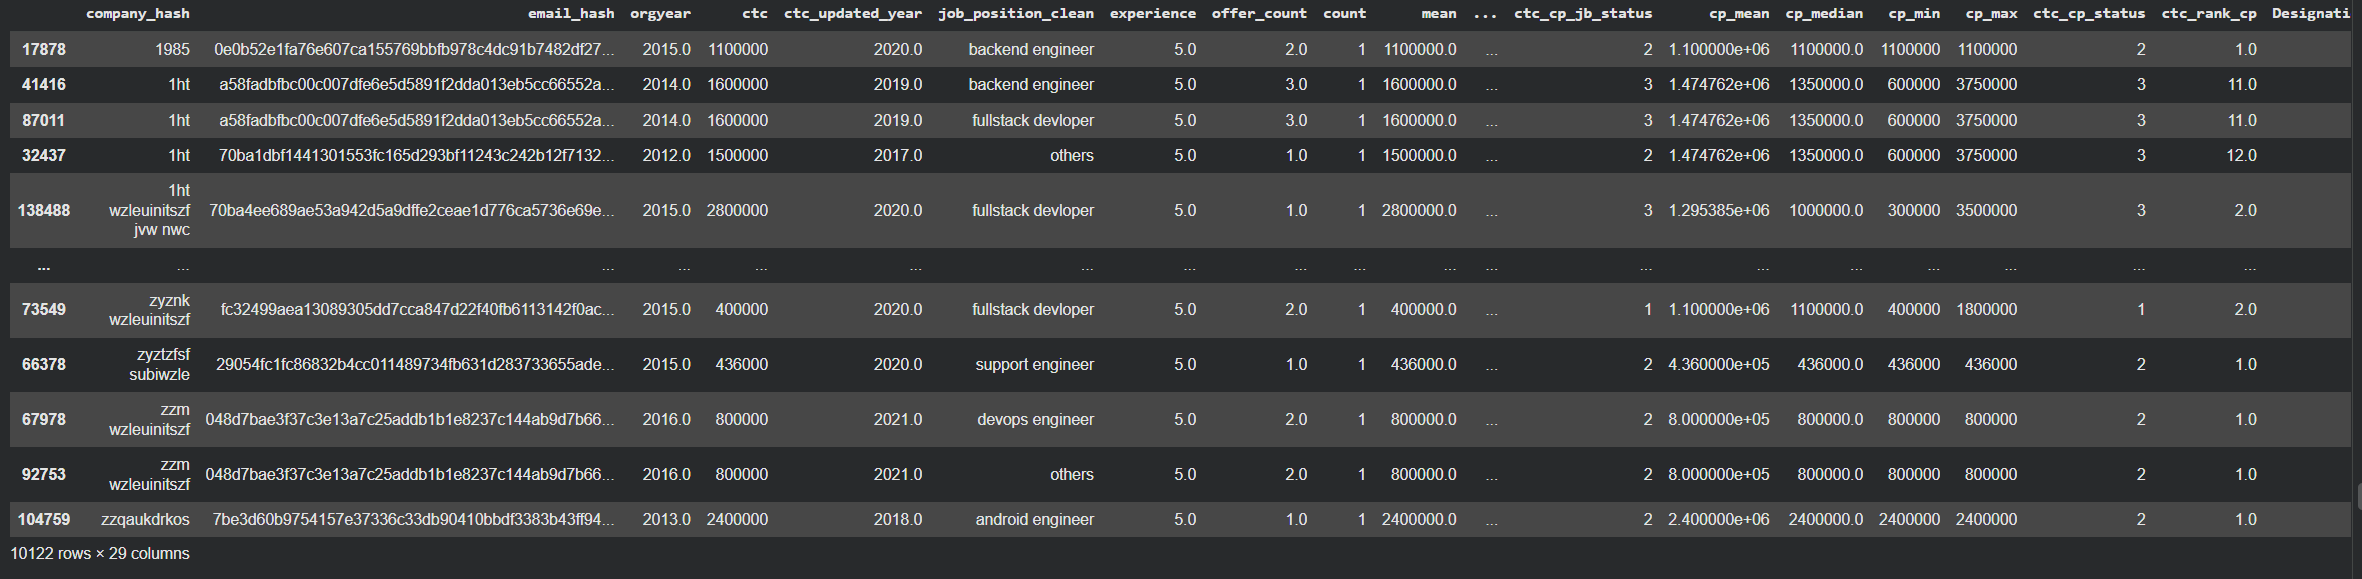

##Unspervised Learning - Clustering
Checking clustering tendency

In [102]:
df_mrg_ctc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139095 entries, 0 to 139094
Data columns (total 26 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   company_hash        139095 non-null  object 
 1   email_hash          139095 non-null  object 
 2   orgyear             139095 non-null  float64
 3   ctc                 139095 non-null  int64  
 4   ctc_updated_year    139095 non-null  float64
 5   job_position_clean  139095 non-null  object 
 6   experience          139095 non-null  float64
 7   offer_count         139095 non-null  float64
 8   count               139095 non-null  int64  
 9   mean                139095 non-null  float64
 10  median              139095 non-null  float64
 11  min                 139095 non-null  int64  
 12  max                 139095 non-null  int64  
 13  ctc_above_avg       139095 non-null  int64  
 14  ctc_status          139095 non-null  int64  
 15  cp_jb_mean          139095 non-nul

In [103]:
#Checking clustering tendency
#Preprocessing Data
df_mrg_ctc_shrink = df_mrg_ctc[['company_hash','job_position_clean','experience','ctc']].copy()

In [104]:
df_mrg_ctc_shrink

,company_hash,job_position_clean,experience,ctc
0,czniswwz sucsk,others,4.0,1100000
1,oznskulz subilihh nshswzc,fullstack devloper,1.0,449999
2,faulwklwsl ks,backend engineer,5.0,2000000
3,wirijzcsk,backend engineer,2.0,700000
4,osbw toidj,fullstack devloper,2.0,1400000
...,...,...,...,...
139090,lft suwzoukwsiukn,fullstack devloper,5.0,1500000
139091,subifaf,fullstack devloper,2.0,1200000
139092,lihjuivk liuwoklw,data scientist,6.0,1000000
139093,cduuedhga,data scientist,2.0,1100000


In [105]:
df_mrg_ctc_shrink.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139095 entries, 0 to 139094
Data columns (total 4 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   company_hash        139095 non-null  object 
 1   job_position_clean  139095 non-null  object 
 2   experience          139095 non-null  float64
 3   ctc                 139095 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [106]:

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

categorical = ['company_hash', 'job_position_clean']
numeric = ['experience','ctc']

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
        ('num', StandardScaler(), numeric)
    ]
)

X_processed = preprocess.fit_transform(df_mrg_ctc_shrink[categorical + numeric])


In [107]:
print(X_processed)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 556380 stored elements and shape (139095, 30468)>
  Coords	Values
  (0, 2329)	1.0
  (0, 30237)	1.0
  (0, 30466)	-0.2261484750716477
  (0, 30467)	-0.23676199012889834
  (1, 19472)	1.0
  (1, 30157)	1.0
  (1, 30466)	-0.9931527130549248
  (1, 30467)	-0.7493226800490187
  (2, 3966)	1.0
  (2, 30068)	1.0
  (2, 30466)	0.029519604256111304
  (2, 30467)	0.47293633483999914
  (3, 26587)	1.0
  (3, 30068)	1.0
  (3, 30466)	-0.7374846337271658
  (3, 30467)	-0.5521834678928528
  (4, 19088)	1.0
  (4, 30157)	1.0
  (4, 30466)	-0.7374846337271658
  (4, 30467)	-0.00019588180593252025
  (5, 3333)	1.0
  (5, 30157)	1.0
  (5, 30466)	-0.7374846337271658
  (5, 30467)	-0.5521834678928528
  (6, 19778)	1.0
  :	:
  (139088, 30467)	-0.35504504429038125
  (139089, 10898)	1.0
  (139089, 30068)	1.0
  (139089, 30466)	-1.2488207923826837
  (139089, 30467)	-0.31561735956988696
  (139090, 15262)	1.0
  (139090, 30157)	1.0
  (139090, 30466)	0.029519604256111304
  (

What the printed output means (row, column) → value
Example:
(0, 2574)    1.0
(0, 33325)   1.0
(0, 33566)  -0.22614919607
(0, 33567)  -0.10437870682

Let’s decode this.
Row 0
These are the non-zero features for the 1st row of your input:
🔹 1.0 in one-hot columns
(0, 2574) = 1.0
(0, 33325) = 1.0

This means:

Column 2574 → one category is active (e.g., "company_hash = X")
Column 33325 → another category is active (e.g., "job_position_clean = Y")

One-hot encoding always produces exactly two 1's for two categorical columns (one for each).

🔹 Negative values in the last two columns
(0, 33566) = -0.2261
(0, 33567) = -0.1043

These are scaled numeric values:



Column indexOriginal featureAfter StandardScaler33566experience(value - μ₁)/σ₁33567ctc(value - μ₂)/σ₂
Since values are below their mean, the z-score is negative.

🔍 Why 33568 columns?
Because:
#columns = (#unique company_hash categories)
          + (#unique job_position_clean categories)
          + 2 numeric columns

Example:


FeatureUnique categoriesColumns producedcompany_hash15,00015,000job_position_clean18,00018,000experiencenumeric1ctcnumeric1
So roughly:
15000 + 18000 + 1 + 1 = 33,002  (close to your ~33,568)

Large one‑hot expansions are very normal for hashed categorical fields.

🔍 Why sparse matrix has only ~588,400 non-zero elements?
Because each row only has:


Column typeCountcompany one-hot1job_position one-hot1scaled numeric2
So per row: 4 non-zero values → 4 entries.
Total rows = 147100
Thus approx non-zero:
147100 × 4 = 588,400   ✔ exactly what you have

This confirms everything is working correctly.

🔥 Intuition (C parallel)
In dense representation, you’d need:
147100 * 33568 ≈ 4.9 billion floats
≈ 39 GB of RAM (float64)

But you are storing only ~588k non-zero values → memory usage reduced by ~100x.
CSR is exactly the optimized way you’d implement this in C.

🧠 Final Summary
What your output means:

Row = sample index
Column = encoded feature index
Value = 1.0 (for one-hot) OR scaled numeric value
Sparse format because 99.9% of matrix is zeros
Shape = (147100, 33568) → very normal for one-hot encoding large categorical features
588,400 non-zero elements = perfect (≈4 per row)

In [108]:
preprocess

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['company_hash', 'job_position_clean']),
                                ('num', StandardScaler(),
                                 ['experience', 'ctc'])])

In [109]:
X_processed

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 556380 stored elements and shape (139095, 30468)>

In [110]:
X_processed

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 556380 stored elements and shape (139095, 30468)>

In [111]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import random

def hopkins(X):
    X = np.array(X)
    n = len(X)
    m = int(0.1 * n)  # sample size

    nbrs = NearestNeighbors(n_neighbors=1).fit(X)

    # random points in same range
    rand_X = np.random.uniform(np.min(X, axis=0), np.max(X, axis=0), (m, X.shape[1]))
    u_dist, _ = nbrs.kneighbors(rand_X)

    # sample real points
    random_indices = random.sample(range(n), m)
    w_dist, _ = nbrs.kneighbors(X[random_indices])

    H = u_dist.sum() / (u_dist.sum() + w_dist.sum())
    return H

In [112]:
X_dense_sample = X_processed[np.random.choice(X_processed.shape[0], 1500, replace=False)].toarray()

In [113]:
h = hopkins(X_dense_sample)


In [114]:
print(h)

0.99999999974162


## Conclusion 6 : Hopkins value 0.99999 indicates very strong clustering Tendency

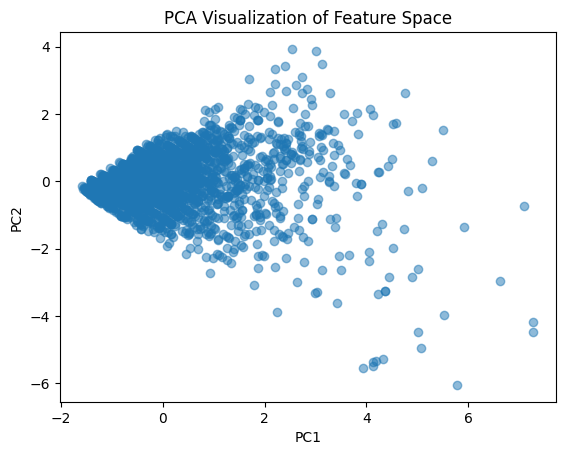

In [115]:
# PCA Plot analysis
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# sample 3000 rows
idx = np.random.choice(X_processed.shape[0], 3000, replace=False)
X_sample = X_processed[idx].toarray()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
plt.title("PCA Visualization of Feature Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

**1. The Plot Shows That Most Variance Is in PC1
PC2 almost carries no variance**


Almost all points lie near PC2 ≈ 0
Only a handful are higher (outliers on PC2)
PC1 spreads widely (from about –1 to +5)

👉 Interpretation

PC1 is capturing almost all meaningful variation in your data.
PC2 contributes very little (almost flat → collapsed to near-zero).

This is typical when:

Your dataset is heavily dominated by one-hot encoded categorical variables (company, role).
One principal direction explains almost the entire structure.
The second dimension doesn't help separate clusters.



In [116]:
# Elbow method

#Limiting sample size as colab is not able to handle larger data size
idx = np.random.choice(X_processed.shape[0], 3000, replace=False)
X_sample = X_processed[idx]


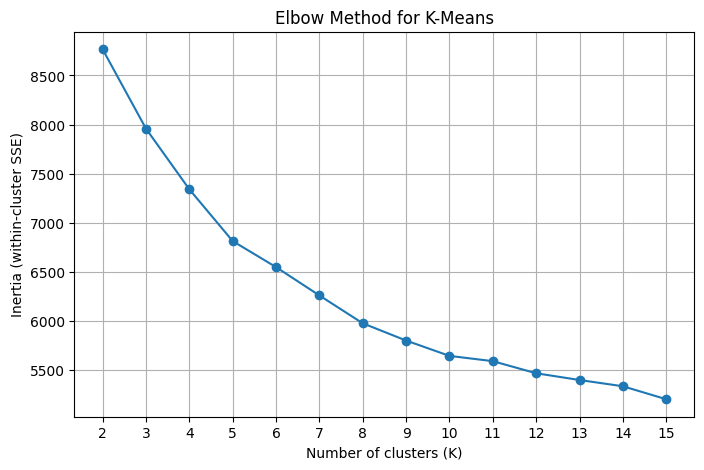

In [117]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = range(2, 16)  # try K = 2 to 15

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init='auto'  # or n_init=10 for older sklearn
    )
    kmeans.fit(X_sample)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(K_range), inertias, marker='o')
plt.xticks(list(K_range))
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (within-cluster SSE)')
plt.title('Elbow Method for K-Means')
plt.grid(True)
plt.show()


##Conclusion 7 : Based on the Elbow method K = 3

In [118]:
##Conclusion 7 : Based on the Elbow method K = 3

In [119]:

from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X_processed)   # X_processed is sparse


In [120]:
X_reduced

array([[-3.60615751e-01, -2.18013193e-02,  1.36601404e-02, ...,
         5.67229370e-04, -2.28648952e-03, -2.61097935e-03],
       [-1.25850935e+00,  2.07472681e-01, -3.72209128e-02, ...,
        -1.77319393e-03, -1.68136672e-04,  3.91043571e-03],
       [ 3.56396283e-01,  4.56271439e-01,  9.40100870e-01, ...,
         2.91859837e-04, -1.32687648e-03, -3.53817312e-03],
       ...,
       [-2.04908421e-02, -4.12330783e-01,  5.95418982e-02, ...,
        -2.19232850e-04, -1.56535300e-03, -3.29001983e-04],
       [-6.85805450e-01,  3.55272806e-01, -5.20309490e-02, ...,
         6.22368003e-04, -1.75371720e-03, -8.72302155e-04],
       [-3.32341603e-01, -2.54179610e-02,  1.02935931e-02, ...,
         9.81399516e-04, -2.64069163e-03, -1.67027011e-03]])

In [121]:

# 2. Fit KMeans on full PCA data
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init='auto')
cluster_labels = kmeans_final.fit_predict(X_reduced)

df_mrg_ctc_shrink['cluster'] = cluster_labels


In [122]:
df_mrg_ctc_shrink['cluster'].unique()

array([1, 2, 0], dtype=int32)

In [123]:
df_mrg_ctc_shrink.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139095 entries, 0 to 139094
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   company_hash        139095 non-null  object 
 1   job_position_clean  139095 non-null  object 
 2   experience          139095 non-null  float64
 3   ctc                 139095 non-null  int64  
 4   cluster             139095 non-null  int32  
dtypes: float64(1), int32(1), int64(1), object(2)
memory usage: 4.8+ MB


In [124]:

cluster_summary = df_mrg_ctc_shrink.groupby('cluster').agg({
    'ctc': ['count', 'mean', 'min', 'max'],
    'experience': 'mean',
    'company_hash': lambda x: x.value_counts().index[0],
    'job_position_clean': lambda x: x.value_counts().index[0]
})

print(cluster_summary.to_string())


            ctc                                  experience               company_hash job_position_clean
          count          mean      min       max       mean                   <lambda>           <lambda>
cluster                                                                                                  
0          7993  5.088158e+06  3000000  13000000   6.755911                     khkqiu   backend engineer
1        102668  9.835382e+05   200000   3500000   3.177991  wkwk liufdnwkula fzovslzf   backend engineer
2         28434  1.868186e+06   200000   5020000  10.520398                     ioklnz   backend engineer


## Conclusion 8 :  Insights from Unsupervised Clustering

**Cluster 0 — High CTC, Highly Specialized Talent**
📌 Size: 7,993 profiles (smallest cluster – top of the pyramid)
📌 Avg CTC: ₹50.8 L
📌 Max CTC: ₹1.3 Cr
📌 Avg Experience: 6.75 years (surprisingly low!)
📌 Dominant Role: Backend Engineer
🔍 Interpretation
This is your high-value, niche salary cluster.
IMPORTANT OBSERVATION:
Despite having only ~6.75 years experience (mid-level),
CTC is extremely high → 30–130 L.
This indicates:
🔥 These are specialized senior engineers, niche startups, FAANG-like roles, or outlier high-paying companies.
🧠 Business Insight
Salary inflation for niche high-performance engineering talent
Competitive pressure from elite tech companies
High salaries not proportional to experience → skill-based premium
This cluster contains roles where pay is dictated by company tier, not just experience


 **Cluster 1 — Entry‑Level / Early‑Career Talent (Majority Segment)**
📌 Size: 102,668 profiles (70% of entire dataset)
📌 Avg CTC: ₹9.8 L
📌 Experience: ~3.2 years
📌 Max CTC: ₹35 L
📌 Dominant Role: Backend Engineer
📌 Dominant Company Hash: wkwk…
🔍 Interpretation
This is your mass market talent pool.
These candidates are:


🧠 Business Insight
Extremely well-defined salary structure
Very low variance → indicates healthy, predictable job market
Ideal pipeline for mass scaling
Bulk recruitment & standard salary grids work well here


**Cluster 2 — Mid‑Senior, Experienced Tech Talent**
📌 Size: 28,434 profiles
📌 Avg CTC: ₹18.6 L
📌 Avg Experience: 10.5 years
📌 CTC Range: 2 L – 50 L
📌 Dominant Role: Backend Engineer
📌 Dominant Company Hash: ioklnz
🔍 Interpretation
This is the core mid-to-senior engineering workforce.

Strong experience (≈10 yrs)
Salary nearly 2× Cluster 1
Clear upward progression
Mixed mid- and senior-level roles
Broader company distribution

🧠 Business Insight
This cluster defines your senior tech compensation benchmark.
Consistent salary progression relative to experience
Healthy market segmentation
The 50 L upper band indicates tech lead / principal roles

## Conclusion 9: - Hierarchical clustering  



In [125]:
sample_df_mrg_ctc_shrink = df_mrg_ctc_shrink

In [126]:
df_mrg_ctc_shrink.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139095 entries, 0 to 139094
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   company_hash        139095 non-null  object 
 1   job_position_clean  139095 non-null  object 
 2   experience          139095 non-null  float64
 3   ctc                 139095 non-null  int64  
 4   cluster             139095 non-null  int32  
dtypes: float64(1), int32(1), int64(1), object(2)
memory usage: 4.8+ MB


In [127]:
X_pca

array([[ 0.92532879, -2.72005785],
       [-0.46723955,  0.19631924],
       [-0.27394733, -0.47967672],
       ...,
       [ 1.87615189,  2.17054585],
       [-0.92253079, -0.20105704],
       [ 2.6932617 ,  1.7264505 ]])

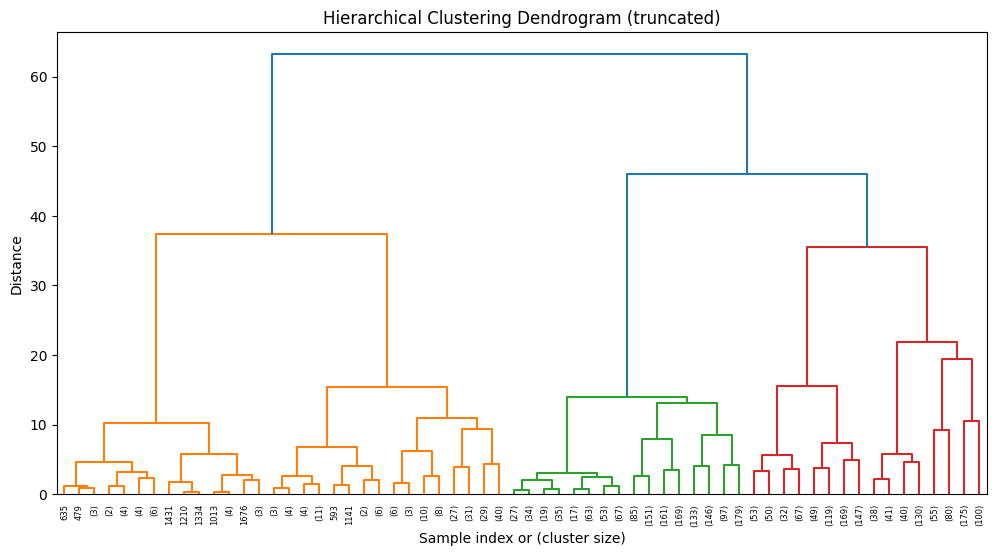

In [128]:

from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# 'ward' linkage works well with Euclidean distance and continuous data
Z = linkage(X_pca, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # truncate to show top merges
plt.title("Hierarchical Clustering Dendrogram (truncated)")
plt.xlabel("Sample index or (cluster size)")
plt.ylabel("Distance")
plt.show()


#Conclusion 9 : Based on Dandogram K = 3 (Orange, Green and Blue)

Insight Meaning
K = 3
Best top-level clusteringVery large height jumpsClusters are strongly separatedSubclusters inside clustersCan do finer segmentation if neededCluster size imbalanceSome job profiles are more commonCluster compactness differsSome groups are very clean, some more spread

#Following is AI Generated output for student's reference:
Here is a clear, **data‑driven interpretation** of your attached dendrogram, with **practical insights** you can use for clustering and your business analysis.

I will explain what the structure shows, how many clusters are appropriate, and what this means for your segmentation (company + role + experience).

***

# 📊 **Hierarchical Clustering Dendrogram – Interpretation**

Your dendrogram shows three colored regions:

*   **Orange cluster (left)**
*   **Green cluster (right)**
*   Both ultimately merge at the very top (\~70 distance)

Let’s decode what this means.

***

# ✅ **1. The dataset has TWO strong, well‑separated clusters**

The single biggest vertical jump happens at the **top blue merge** at height \~70.

This means:

👉 **Two major clusters** naturally exist in your data

*   Left side = Orange
*   Right side = Green

These two groups are **very different in feature space**  
(company\_hash, job\_position\_clean, experience).

This is reinforced by:

*   Large vertical distance
*   No early merging between orange and green
*   Clear separation at mid‑distance levels

***

# ✅ **2. Within each major cluster, there are meaningful subclusters**

### **Orange Section (Left)**

*   Internal merges happen mostly at height **5–25**
*   Indicates a **homogeneous** group with:
    *   similar role patterns
    *   similar experience bands
    *   companies with similar compensation profile

This often corresponds to:
👉 **Early to mid‑career common roles** (e.g., backend engineers in typical companies)

***

### **Green Section (Right)**

*   Internal merges occur at height **10–40**
*   This cluster is more **spread-out and diverse**
*   Contains:
    *   broader role variations
    *   broader experience range
    *   higher salary variance segments

This often corresponds to:
👉 **Senior / advanced / niche talent**  
with more variability in salary behavior.

***

# ✅ **3. Natural number of clusters = 2 or 3**

Based on merge heights:

### ✔ If you want **broad segmentation**:

**Cut at height \~45** → **2 clusters**

*   Orange group
*   Green group

### ✔ If you want **meaningful but finer segmentation**:

**Cut at height \~25** → **3 clusters**

*   Orange cluster splits into 2 subclusters
*   Green cluster remains as 1 big subcluster

### ✔ If you want **very fine segmentation** for salary bands:

Cut at height \~10 → 5–7 clusters

But **2 or 3** are the most defensible based on dendrogram structure.

***

# ✅ **4. Orange vs Green: What differences does the dendrogram reveal?**

### **Orange group (left)**

*   Tighter, lower-distance merges
*   More consistency
*   More predictable salary and experience distribution
*   High volume profiles
*   Likely your **junior → mid-level** population

### **Green group (right)**

*   Larger distances
*   Wider spread
*   More variability in role/company patterns
*   Contains smaller but more distinct pockets
*   Likely your **mid → senior** or **premium** population

***

# 📌 **5. Business Insight from Cluster Structure**

Even without salary in the dendrogram, this structure already reveals:

### **Insight 1 – Two distinct talent markets exist**

One aligned across standard roles/companies (orange),  
and one broader and more complex (green).

### **Insight 2 – The green cluster indicates salary diversity**

Because merges happen at higher distances, salary is likely more varied.

### **Insight 3 – Orange cluster is ideal for strict salary banding**

Due to compactness and low distance between subclusters.

### **Insight 4 – Green cluster requires more flexible compensation rules**

Due to greater heterogeneity—probably seniority or niche role effects.

### **Insight 5 – You can align salary normalization strategy accordingly:**

*   Cluster A (Orange): **fixed, standardized compensation grid**
*   Cluster B (Green): **experience/company‑tier sensitive compensation**

This aligns with your earlier GROUPBY insights where  
Cluster 1 (junior), Cluster 2 (senior), Cluster 0 (high‑salary niche) emerged.

***

# 🎯 **6. Recommended Next Step**

If your goal is salary segmentation:

*   **Use K = 3**  
    It matches the dendrogram’s fine-level structure  
    and your salary cluster summary (entry, mid, niche).

If you want broader segmentation:

*   **Use K = 2**  
    Simple split between standard and advanced talent.

***
